# Neighborhood analysis with just immune cells and based on comparisons of interest

Poportions will be calculated based on the subset of immune cells in each ROI.

In [217]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import time
import sys
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import seaborn as sns
import math
import os
import re

from scipy.spatial import cKDTree
from scipy.spatial import distance_matrix
from scipy.stats import ttest_ind
from scipy.stats import ttest_rel
from itertools import combinations
import pandas as pd
import statsmodels.stats.multitest as smm

from scipy import stats


import matplotlib.cm as cm
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [218]:
import matplotlib.pyplot as plt
plt.rcdefaults()


I am working with these ROIs in here:

In [219]:
path = "/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/"

all_files = os.listdir(path)
pattern = re.compile(r'(.+)_sigma_binary_res')

# Extract matching sample names
sample_names = []
for file in all_files:
    match = pattern.match(file)
    if match:
        sample_names.append(match.group(1)) 

In [220]:
sample_names

['23257_A7_T3_tumor_bed',
 'BMS23-6679_C_tumor',
 'S23-38315_A3_tumor_inner',
 'BMS23-11362_C8_tumor_inner',
 'BMSS23-8749_28835_tumor',
 'S24-12214_C1_tumor',
 'BMS23-9784_A6_31737_tumor_bed',
 'S24-22889_A6_tumor_inner',
 'S23-47115_A6_tumor_bed',
 'S24-11672_G1_tumor',
 'S23-18584_A5_tumor_bed',
 'S24-35674_A9_tumor_inner',
 'S24-21915_A5_tumor_bed',
 'S23-21917_A6_tumor_bed',
 'BMS23-7393_C_tumor',
 'BMS24-11260_D_tumor',
 'BMS23-39313_C_tumor']

In [221]:
#create def to create a new table:
all_sample_merged_table= []
for sample_name in sample_names:
    annota_table = pd.read_table(f'/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/{sample_name}_sigma_binary_res/cell_annotation.txt')
    raw_table = pd.read_csv(f'/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/{sample_name}_sigma_binary_res/raw_metadata.csv')
    #print(annota_table['cell_id'].isin(raw_table['Object Id']).all())
    merged_table = pd.merge(
        raw_table,
        annota_table,
        left_on='Object Id',
        right_on='cell_id',
        how='inner'
    )
    merged_table['sample_region']=sample_name
    all_sample_merged_table.append(merged_table)

all_sample_merged_table = pd.concat(all_sample_merged_table, axis=0).reset_index(drop=True)

In [222]:
all_zscore_table= []
for sample_name in sample_names:
    norm_data = pd.read_csv(f'/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/{sample_name}_sigma_binary_res/z_score_normalization.csv')
    norm_data['sample_region']=sample_name
    all_zscore_table.append(norm_data)

all_zscore_table = pd.concat(all_zscore_table, axis=0).reset_index(drop=True)

In [223]:
all_sample_merged_table2 = all_sample_merged_table

In [224]:
all_sample_merged_table2.loc[all_sample_merged_table2['sample_region'] == 'BMS23-11362_C8_tumor_inner', 'sample_region'] = 'BMS23-11362_C8_tumor_bed'

In [225]:
normalized_df = all_sample_merged_table2.merge(all_zscore_table, on=['cell_id', 'sample_region'], how='left')


In [226]:
#rename cell types
probes_list =pd.read_csv("/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/probes_cell_type_table.csv",header=0)
normalized_df = pd.merge(normalized_df, probes_list, on="celll_type")

In [227]:
#select just the sample names, cell type of interest, X_mean and Y_mean and Cell Area
columns_to_Select = ['sample_region','new_cell_type_name','Cell Area (µm²)','xmean', 'ymean']
sub_df = normalized_df[columns_to_Select]

In [228]:
#sub_df

In [229]:
#they have decided to combine cell types.
sub_df["combined_names"]=sub_df["new_cell_type_name"]
sub_df.loc[sub_df['new_cell_type_name'] == 'CD4', 'combined_names'] = 'CD4_T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD3E_CD4 (CD4_Tcell)', 'combined_names'] = 'CD4_T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD4_LAG3_Tcell', 'combined_names'] = 'CD4_T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD8', 'combined_names'] = 'CD8_T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD3E_CD8 (CD8_Tcell)', 'combined_names'] = 'CD8_T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD8_LAG3_Tcell', 'combined_names'] = 'CD8_T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD3E_CD4_CD8 (Tcell)', 'combined_names'] = 'T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'LAG3_Tcell', 'combined_names'] = 'T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'FOXP3', 'combined_names'] = 'T_reg'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD3E_FOXP3 (T_regs)', 'combined_names'] = 'T_reg'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD3E_CD8_FOXP3 (CD8_Tregs)', 'combined_names'] = 'CD8_Treg'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD3E_CD4_FOXP3 (CD4_Tregs)', 'combined_names'] = 'CD4_Treg'
sub_df.loc[sub_df['new_cell_type_name'] == 'Macrophages', 'combined_names'] = 'M1_Macrophages'
sub_df.loc[sub_df['new_cell_type_name'] == 'Th2_Macrophage', 'combined_names'] = 'M2_Macrophages'

/tmp/ipykernel_15461/3522644170.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df["combined_names"]=sub_df["new_cell_type_name"]


In [230]:
#sub_df["combined_names"].value_counts()

In [231]:
celltype_colors = {
    "NK": "#1f77b4",
    "CD8_T_cell": "#2ca02c",
    "Endothelial": "#d62728",
    "Unknown": "#843c39",
    "B_cell": "#8c564b",
    "T_reg": "#e377c2",
    "Lymphatic_endothelium": "#7f7f7f",
    "Smooth_muscle": "#aec7e8",
    "CD8_Treg": "#ffbb78",
    "CD4_T_cell": "#98df8a",
    "M1_Macrophages": "#c5b0d5",
    "T_cell": "#c49c94",
    "Epithelial": "#f7b6d2",
    "CD4_Treg": "#393b79",
    "Stromal": "#637939",
    "M2_Macrophages": "#ff9896",
    "Plasma": "#9467bd"
}

## Subset for just immune cells.

In [232]:
immune_cells = ['B_cell', 'CD4_T_cell', 'CD4_Treg','CD8_T_cell', 'CD8_Treg','Plasma',"T_reg", 'M1_Macrophages', 'M2_Macrophages']

In [233]:
sub_df_immune = sub_df[sub_df['combined_names'].isin(immune_cells)]

## Number of immune cells per sample

In [234]:
pd.crosstab(sub_df_immune['sample_region'], sub_df_immune['combined_names'])


combined_names,B_cell,CD4_T_cell,CD4_Treg,CD8_T_cell,CD8_Treg,M1_Macrophages,M2_Macrophages,Plasma,T_reg
sample_region,,,,,,,,,
23257_A7_T3_tumor_bed,8210,888,4,14697,110,157,0,0,1324
BMS23-11362_C8_tumor_bed,1726,50,0,3471,2,286,7,42,1577
BMS23-39313_C_tumor,466,754,137,298,5,108,0,124,269
BMS23-6679_C_tumor,233,82,37,16,3,121,1,268,427
BMS23-7393_C_tumor,512,91,51,69,3,29,19,1717,619
BMS23-9784_A6_31737_tumor_bed,15411,608,19,40992,20,352,50,17636,2203
BMS24-11260_D_tumor,31,323,82,46,0,40,1,48,444
BMSS23-8749_28835_tumor,534,2894,218,551,1,142,18,7,2263
S23-18584_A5_tumor_bed,13923,58,1,2284,0,64,5,164,2009


### Total number of immune cells per genotype

In [235]:
sub_df_immune['sample_region'].value_counts()

sample_region
BMS23-9784_A6_31737_tumor_bed    77291
23257_A7_T3_tumor_bed            25390
S23-18584_A5_tumor_bed           18508
S24-35674_A9_tumor_inner         15288
S24-12214_C1_tumor               10747
S24-21915_A5_tumor_bed           10145
BMS23-11362_C8_tumor_bed          7161
BMSS23-8749_28835_tumor           6628
S24-22889_A6_tumor_inner          6039
S23-38315_A3_tumor_inner          5906
S23-47115_A6_tumor_bed            5660
S24-11672_G1_tumor                4667
BMS23-7393_C_tumor                3110
BMS23-39313_C_tumor               2161
BMS23-6679_C_tumor                1188
BMS24-11260_D_tumor               1015
S23-21917_A6_tumor_bed             210
Name: count, dtype: int64

In [236]:
regions = ["tumor_inner", "tumor_bed", "tumor"]

# Create regex pattern
pattern = re.compile(rf"({'|'.join(regions)})$")

# Split into sample_id and region
data = []
for s in sub_df_immune['sample_region']:
    match = pattern.search(s)
    if match:
        region = match.group(1)
        sample_id = s.replace("_" + region, "")
    else:
        region = "other"
        sample_id = s
    data.append((sample_id, region))

df = pd.DataFrame(data, columns=["Sample_name", "ROI"])

In [237]:
sub_df_immune['Sample_name']=df['Sample_name'].values
sub_df_immune['ROI']=df['ROI'].values

/tmp/ipykernel_15461/241085061.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df_immune['Sample_name']=df['Sample_name'].values
/tmp/ipykernel_15461/241085061.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df_immune['ROI']=df['ROI'].values


In [238]:
sample_map = pd.read_csv("/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/sample_conditions.csv")  
sample_map

,Sample_name,ROI,Condition,MSI,Internal
0,23257_A7_T3,tumor_bed,Responder,Stable,Resection
1,BMS23-11362_C8,tumor_bed,Responder,High,NaN
2,BMS23-39313_C,tumor,Responder,Stable,Baseline
3,BMS23-6679_C,tumor,Baseline,Stable,Baseline
4,BMS23-7393_C,tumor,Baseline,High,Baseline
5,BMS23-9784_A6_31737,tumor_bed,Responder,High,Resection
6,BMS24-11260_D,tumor,Baseline,Stable,Baseline
7,BMSS23-8749_28835,tumor,Non-responder,Stable,Resection
8,S23-18584_A5,tumor_bed,Responder,Stable,NaN
9,S23-21917_A6,tumor_bed,Responder,Stable,NaN


In [239]:
sub_df_immune = pd.merge(
    sub_df_immune, sample_map,
    left_on=["Sample_name", "ROI"],
    right_on=["Sample_name", "ROI"],
    how="inner"
)


# Spatial nieghbors

## Spatial nieghbors by Conditions

Here we are computing for each cell type which is the proportion of other cell types wihin 50 microns. Based on differnet conditions.

In [240]:
np.random.seed(42)

def neighbor_enrichment(df, sample_col="sample_region", cell_type_col="new_cell_type_name", radius=20.0, cond=None):
    """
    Computes the counts and proportions of neighbor cell types within a given radius
    for each cell type in the dataset, aggregated over all samples.

    Returns:
        neighbor_summary_df: DataFrame with cell types as rows, neighbor types as columns,
                             values are proportion of neighbors.
    """
    neighbor_summary = []

    for cell_type_interest in df[cell_type_col].unique():
        all_neighbors = []

        for sample in df[sample_col].unique():
            df_sample = df[df[sample_col] == sample]
            coords_sample = df_sample[['xmean', 'ymean']].values

            is_interest = df_sample[cell_type_col] == cell_type_interest
            interest_coords = coords_sample[is_interest.values]

            if len(interest_coords) == 0:
                continue

            other_coords = coords_sample[~is_interest.values]
            other_cell_types = df_sample.loc[~is_interest, cell_type_col].values

            if len(other_coords) == 0:
                continue
            #cKDTree → efficient spatial index for nearest-neighbor search.
            #query_ball_point → returns indices of all other cells within radius for each cell of interest.
            tree = cKDTree(other_coords)
            neighbor_idx_list = tree.query_ball_point(interest_coords, r=radius)

            # Flatten neighbor types
            for neighbors in neighbor_idx_list:
                if len(neighbors) > 0:
                    all_neighbors.extend(other_cell_types[neighbors])

        # Count and normalize
        neighbor_counts = pd.Series(all_neighbors).value_counts()
        neighbor_proportions = neighbor_counts / neighbor_counts.sum() if len(neighbor_counts) > 0 else pd.Series()

        # Add cell type info
        for neighbor_type, prop in neighbor_proportions.items():
            neighbor_summary.append({
                "cell_type": cell_type_interest,
                "neighbor_cell_type": neighbor_type,
                "proportion": prop
            })

    neighbor_summary_df = pd.DataFrame(neighbor_summary)

    # Optional: pivot for heatmap
    pivot_df = neighbor_summary_df.pivot(index="cell_type", columns="neighbor_cell_type", values="proportion").fillna(0)

    # Plot heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_df, cmap="viridis", annot=False, fmt=".2f")
    plt.xlabel("Neighbor cell type")
    plt.ylabel("Cell type of interest")
    plt.title(f"Neighbor enrichment within {radius} microns for {cond}")
    plt.tight_layout()
    plt.show()

    return neighbor_summary_df, pivot_df


Samples to compute the neighbor analysis: ['23257_A7_T3_tumor_bed' 'BMS23-11362_C8_tumor_bed' 'S24-12214_C1_tumor'
 'BMS23-9784_A6_31737_tumor_bed' 'S23-47115_A6_tumor_bed'
 'S24-11672_G1_tumor' 'S23-18584_A5_tumor_bed' 'S24-21915_A5_tumor_bed'
 'S23-21917_A6_tumor_bed' 'BMS23-39313_C_tumor']


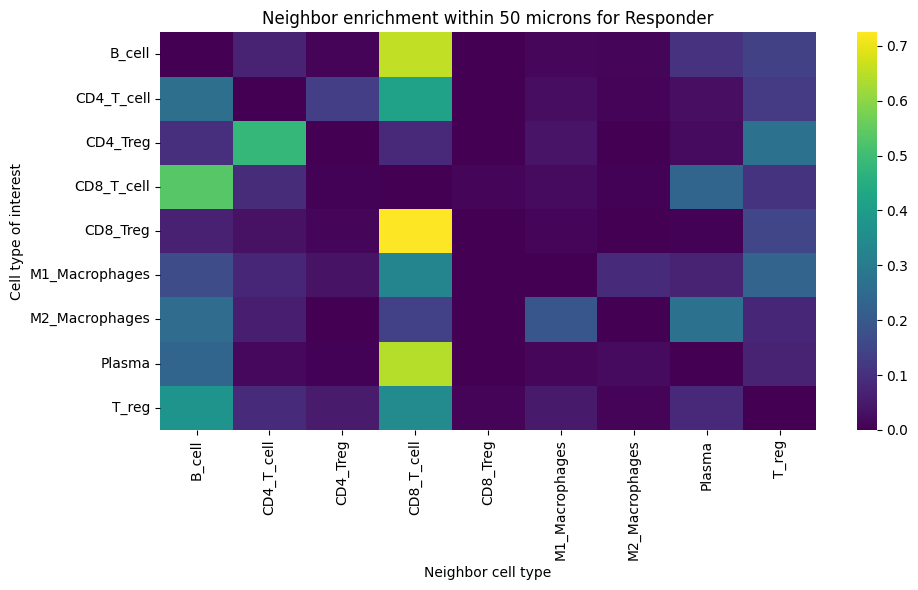

Samples to compute the neighbor analysis: ['BMS23-6679_C_tumor' 'BMS23-7393_C_tumor' 'BMS24-11260_D_tumor']


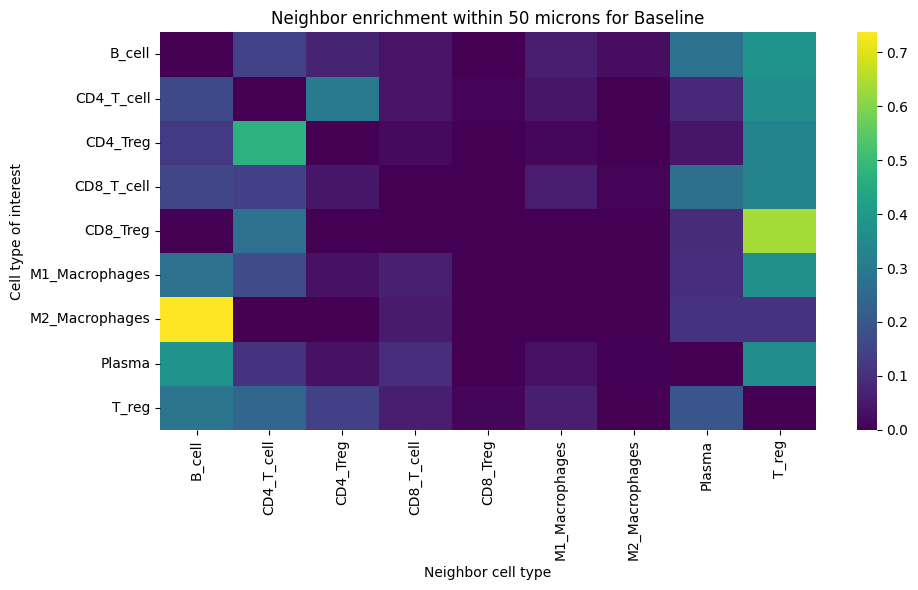

Samples to compute the neighbor analysis: ['S23-38315_A3_tumor_inner' 'BMSS23-8749_28835_tumor'
 'S24-22889_A6_tumor_inner' 'S24-35674_A9_tumor_inner']


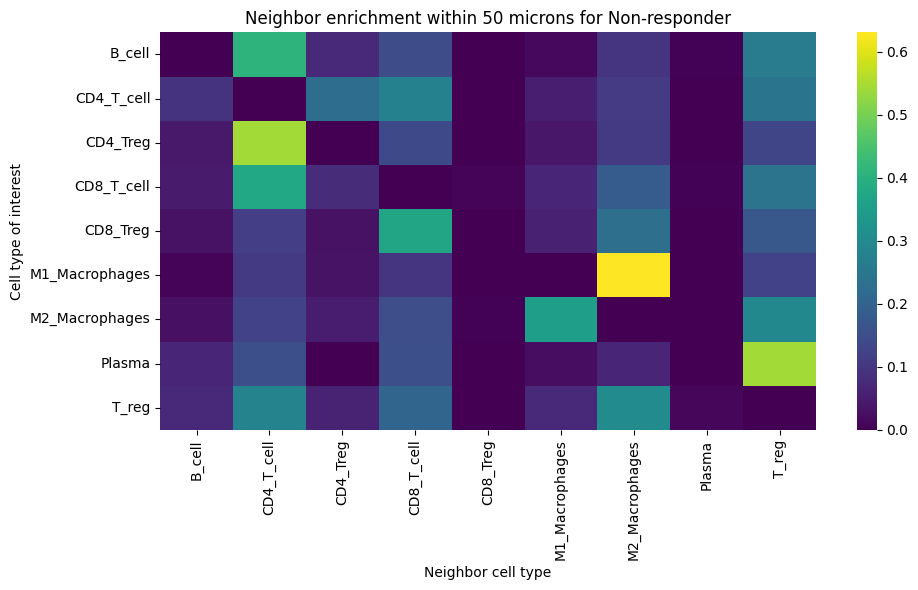

In [241]:
conditions = sub_df_immune['Condition'].unique()

neighbor_dfs = {}  # Store results per condition
pivot_dfs = {}

for cond in conditions:
    df_cond = sub_df_immune[sub_df_immune['Condition'] == cond]
    print(f"Samples to compute the neighbor analysis: {df_cond['sample_region'].unique()}")
    neighbor_summary_df, pivot_df = neighbor_enrichment(
        df_cond,
        sample_col="sample_region",
        cell_type_col="combined_names",
        radius=50,
        cond=cond
    )
    
    neighbor_dfs[cond] = neighbor_summary_df
    pivot_dfs[cond] = pivot_df

## Spatial neighbors by ROI

In [242]:
sub_df_immune.loc[sub_df_immune['sample_region'] == 'BMSS23-8749_28835_tumor', 'ROI'] = 'tumor_inner'


Samples to compute the neighbor analysis: ['23257_A7_T3_tumor_bed' 'BMS23-11362_C8_tumor_bed'
 'BMS23-9784_A6_31737_tumor_bed' 'S23-47115_A6_tumor_bed'
 'S23-18584_A5_tumor_bed' 'S24-21915_A5_tumor_bed'
 'S23-21917_A6_tumor_bed']


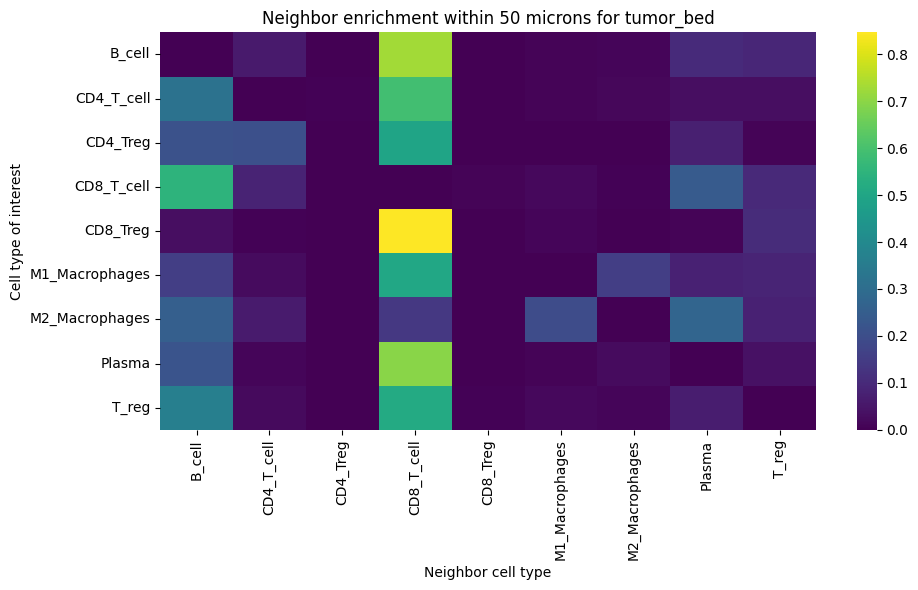

Samples to compute the neighbor analysis: ['BMS23-6679_C_tumor' 'S24-12214_C1_tumor' 'S24-11672_G1_tumor'
 'BMS23-7393_C_tumor' 'BMS24-11260_D_tumor' 'BMS23-39313_C_tumor']


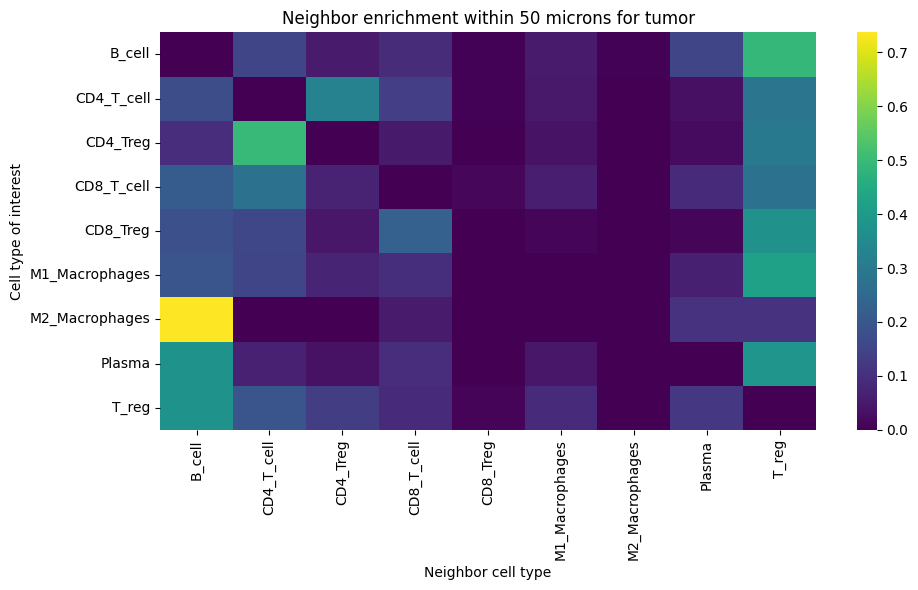

Samples to compute the neighbor analysis: ['S23-38315_A3_tumor_inner' 'BMSS23-8749_28835_tumor'
 'S24-22889_A6_tumor_inner' 'S24-35674_A9_tumor_inner']


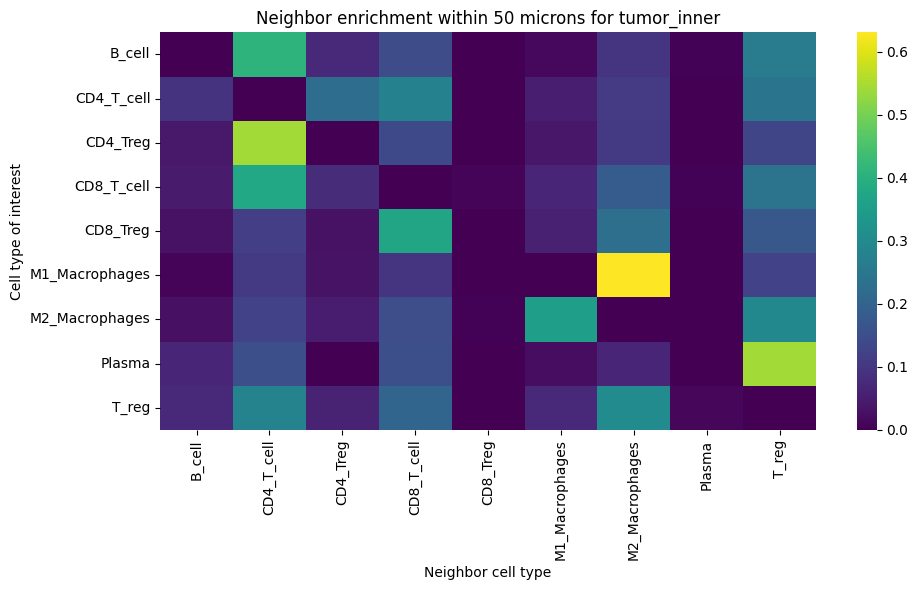

In [243]:
conditions = sub_df_immune['ROI'].unique()

neighbor_dfs = {}  # Store results per condition
pivot_dfs = {}

for cond in conditions:
    df_cond = sub_df_immune[sub_df_immune['ROI'] == cond]
    print(f"Samples to compute the neighbor analysis: {df_cond['sample_region'].unique()}")
    neighbor_summary_df, pivot_df = neighbor_enrichment(
        df_cond,
        sample_col="sample_region",
        cell_type_col="combined_names",
        radius=50,
        cond=cond
    )
    
    neighbor_dfs[cond] = neighbor_summary_df
    pivot_dfs[cond] = pivot_df

In [244]:
sub_df_immune.loc[sub_df_immune['sample_region'] == 'BMSS23-8749_28835_tumor', 'ROI'] = 'tumor'


In [245]:
conditions_interest = ["Responder","Non-responder"]
ROI_interest = ["tumor_bed","tumor_inner"]

In [246]:
sub_interest1 = sub_df_immune[sub_df_immune['Condition'].isin(conditions_interest)]
sub_interest1 = sub_interest1[sub_interest1['ROI'].isin(ROI_interest)]


## MSI High vs MSI stable: all Responders and Non-responders

In [247]:
samples_to_subset = ['BMS23-11362_C8_tumor_bed', 'BMS23-9784_A6_31737_tumor_bed',
       '23257_A7_T3_tumor_bed', 'S23-18584_A5_tumor_bed',
       'S23-21917_A6_tumor_bed', 'S23-47115_A6_tumor_bed',
       'S24-21915_A5_tumor_bed']
MSI_samples = sub_df_immune[sub_df_immune['sample_region'].isin(samples_to_subset)]
MSI_samples['sample_region'].unique()

array(['23257_A7_T3_tumor_bed', 'BMS23-11362_C8_tumor_bed',
       'BMS23-9784_A6_31737_tumor_bed', 'S23-47115_A6_tumor_bed',
       'S23-18584_A5_tumor_bed', 'S24-21915_A5_tumor_bed',
       'S23-21917_A6_tumor_bed'], dtype=object)

Samples to compute the neighbor analysis: ['23257_A7_T3_tumor_bed' 'S23-47115_A6_tumor_bed' 'S23-18584_A5_tumor_bed'
 'S24-21915_A5_tumor_bed' 'S23-21917_A6_tumor_bed']


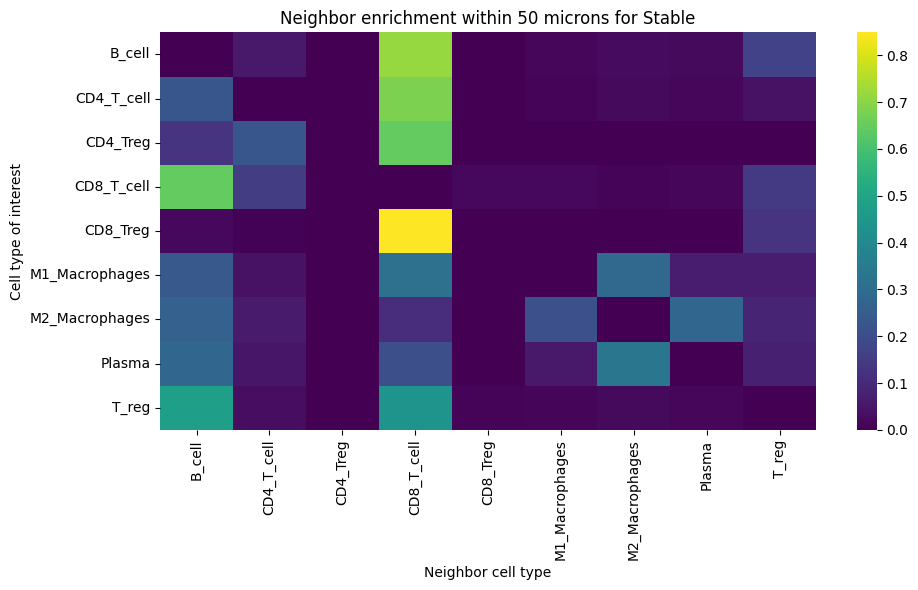

Samples to compute the neighbor analysis: ['BMS23-11362_C8_tumor_bed' 'BMS23-9784_A6_31737_tumor_bed']


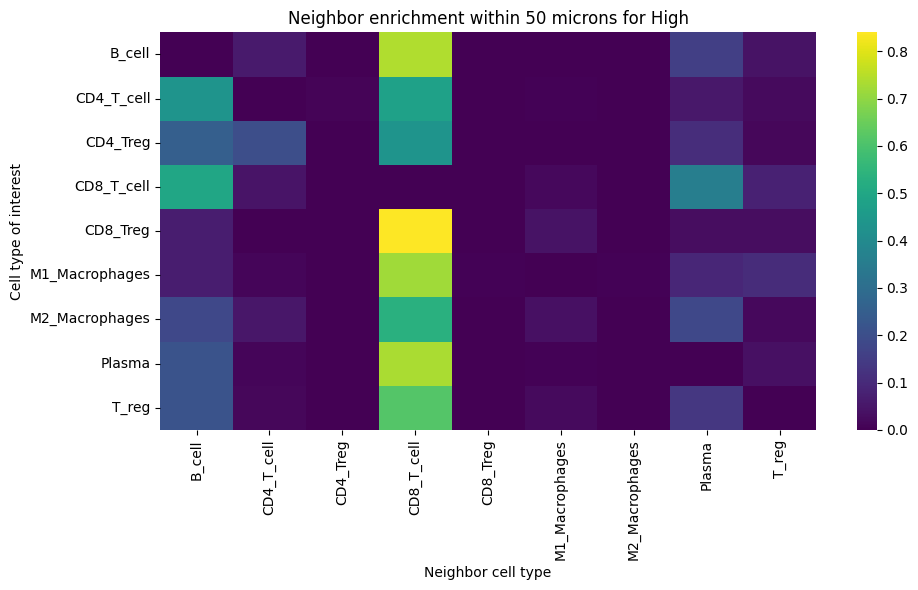

In [248]:
conditions = MSI_samples['MSI'].unique()

neighbor_dfs = {}  # Store results per condition
pivot_dfs = {}

for cond in conditions:
    df_cond = MSI_samples[MSI_samples['MSI'] == cond]
    print(f"Samples to compute the neighbor analysis: {df_cond['sample_region'].unique()}")
    neighbor_summary_df, pivot_df = neighbor_enrichment(
        df_cond,
        sample_col="sample_region",
        cell_type_col="combined_names",
        radius=50,
        cond=cond
    )
    
    neighbor_dfs[cond] = neighbor_summary_df
    pivot_dfs[cond] = pivot_df

## In Responders: MSI High vs MSI stable

In [249]:
MSI_RESPONDERS = MSI_samples[MSI_samples['Condition']=='Responder']
conditions = MSI_RESPONDERS['MSI'].unique()
conditions


array(['Stable', 'High'], dtype=object)

Samples to compute the neighbor analysis: ['23257_A7_T3_tumor_bed' 'S23-47115_A6_tumor_bed' 'S23-18584_A5_tumor_bed'
 'S24-21915_A5_tumor_bed' 'S23-21917_A6_tumor_bed']


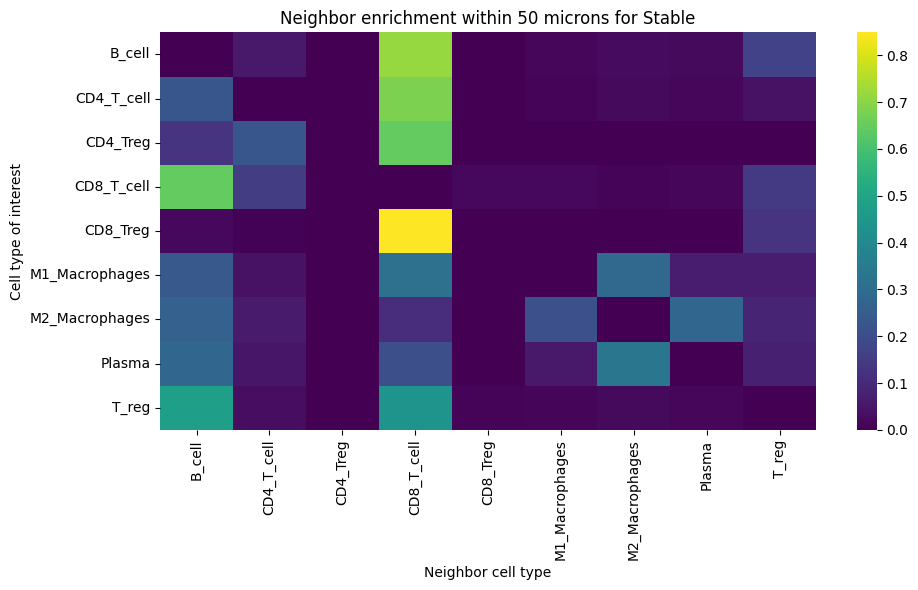

Samples to compute the neighbor analysis: ['BMS23-11362_C8_tumor_bed' 'BMS23-9784_A6_31737_tumor_bed']


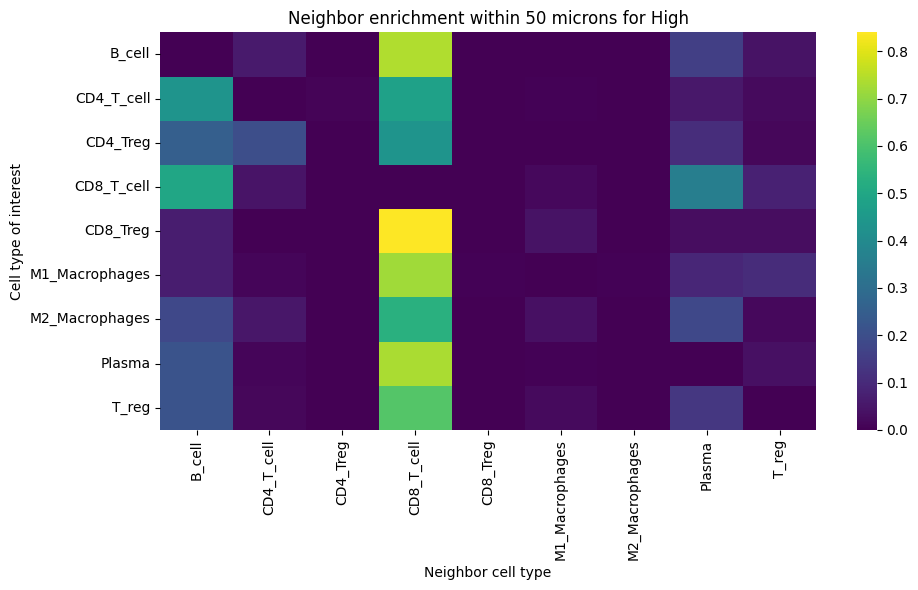

In [250]:
neighbor_dfs = {}  # Store results per condition
pivot_dfs = {}

for cond in conditions:
    df_cond = MSI_RESPONDERS[MSI_RESPONDERS['MSI'] == cond]
    print(f"Samples to compute the neighbor analysis: {df_cond['sample_region'].unique()}")
    neighbor_summary_df, pivot_df = neighbor_enrichment(
        df_cond,
        sample_col="sample_region",
        cell_type_col="combined_names",
        radius=50,
        cond=cond
    )
    
    neighbor_dfs[cond] = neighbor_summary_df
    pivot_dfs[cond] = pivot_df

## Mutation status
In Non-responders WT, KRAS and BRAF

In [251]:
samples_to_subset = ['S24-35674_A9_tumor_inner','S24-22889_A6_tumor_inner','S23-38315_A3_tumor_inner','BMSS23-8749_28835_tumor']
mutation_Samples = sub_df_immune[sub_df_immune['sample_region'].isin(samples_to_subset)]
mutation_Samples['mutation_state']='WT'
mutation_Samples.loc[mutation_Samples['sample_region'] == 'S24-22889_A6_tumor_inner', 'mutation_state'] = 'BRAF_V600R'
mutation_Samples.loc[mutation_Samples['sample_region'] == 'S24-35674_A9_tumor_inner', 'mutation_state'] = 'KRAS_G12D'


/tmp/ipykernel_15461/268937793.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutation_Samples['mutation_state']='WT'


Samples to compute the neighbor analysis: ['S23-38315_A3_tumor_inner' 'BMSS23-8749_28835_tumor']


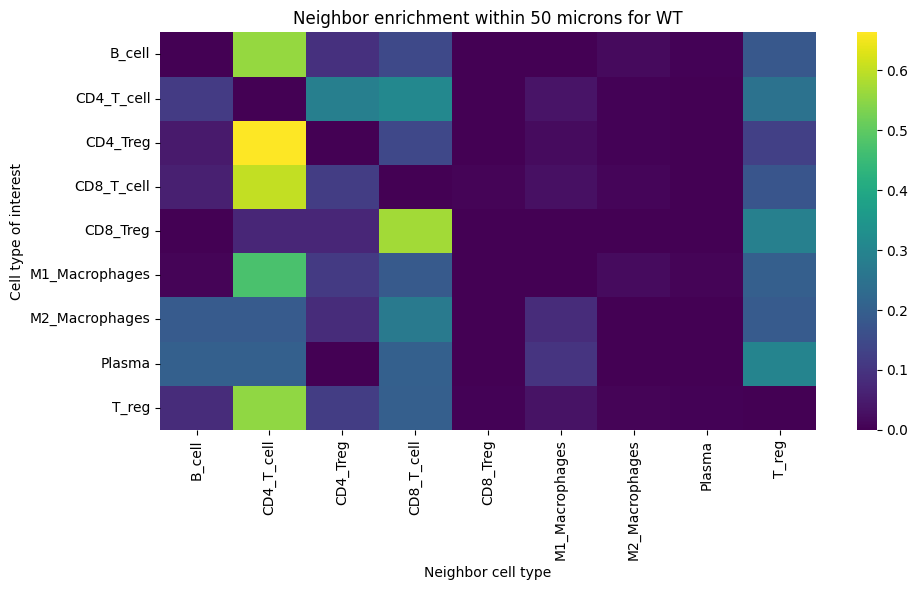

Samples to compute the neighbor analysis: ['S24-22889_A6_tumor_inner']


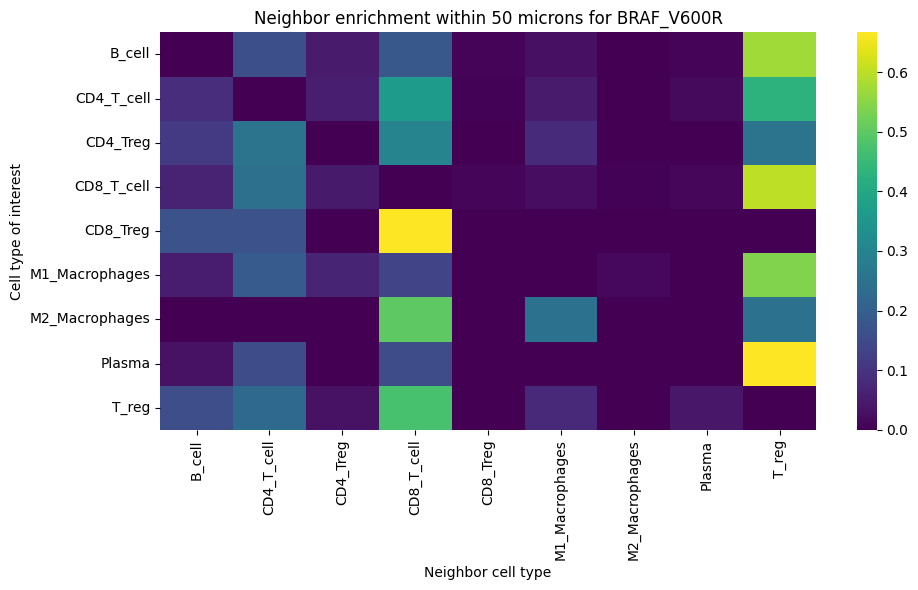

Samples to compute the neighbor analysis: ['S24-35674_A9_tumor_inner']


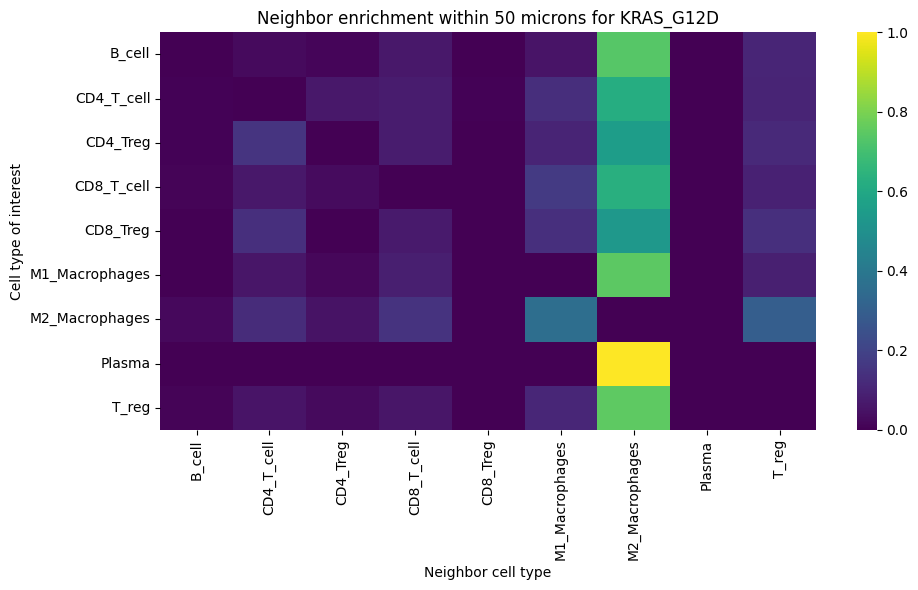

In [252]:
conditions = mutation_Samples['mutation_state'].unique()
neighbor_dfs = {}  # Store results per condition
pivot_dfs = {}

for cond in conditions:
    df_cond = mutation_Samples[mutation_Samples['mutation_state'] == cond]
    print(f"Samples to compute the neighbor analysis: {df_cond['sample_region'].unique()}")
    neighbor_summary_df, pivot_df = neighbor_enrichment(
        df_cond,
        sample_col="sample_region",
        cell_type_col="combined_names",
        radius=50,
        cond=cond
    )
    
    neighbor_dfs[cond] = neighbor_summary_df
    pivot_dfs[cond] = pivot_df

## Calculate distances between specific cell types for Respobders vs Non-responders

In [253]:
#sub_df_immune['combined_names'].unique()

In [254]:
np.random.seed(42)

def nn_dists(coords, source_idx, target_idx, k=1):
    """Compute nearest neighbor distances from source to target coordinates."""
    if len(source_idx) == 0 or len(target_idx) == 0:
        return np.array([])
    tree = cKDTree(coords[target_idx])
    dists, _ = tree.query(coords[source_idx], k=k)
    return dists if k > 1 else dists.ravel()


# --- Compute per-sample distances ---
results = []
radius = 50.0  # microns or pixels; adjust to your spatial scale



In [255]:
results = []

for sample in sub_df_immune['sample_region'].unique():
    sub = sub_df_immune[sub_df_immune['sample_region'] == sample].reset_index(drop=True)
    coords = sub[['xmean', 'ymean']].to_numpy()

    # all unique cell types present in this sample
    cell_types = sub['combined_names'].unique()

    # precompute indices for each cell type
    idx_map = {
        ct: np.where(sub['combined_names'] == ct)[0]
        for ct in cell_types
    }

    # iterate over every ordered pair of distinct cell types
    for src in cell_types:
        for tgt in cell_types:
            if src == tgt:
                continue  # skip self-distances

            dists = nn_dists(coords, idx_map[src], idx_map[tgt], k=1)

            def summarize(metric, dists):
                if len(dists) == 0:
                    return {
                        'sample': sample,
                        'metric': metric,
                        'n_source': 0,
                        'mean': np.nan,
                        'median': np.nan,
                        'prop_within_R': np.nan,
                    }
                return {
                    'sample': sample,
                    'metric': metric,
                    'n_source': len(dists),
                    'mean': float(np.nanmean(dists)),
                    'median': float(np.nanmedian(dists)),
                    'prop_within_R': float(np.mean(dists <= radius)),
                }

            metric_name = f"{src}_to_{tgt}"
            results.append(summarize(metric_name, dists))

res_df = pd.DataFrame(results)


In [256]:
sample_map['sample'] = sample_map['Sample_name'].astype(str) + '_' + sample_map['ROI'].astype(str)

In [257]:
res_df = pd.merge(
    res_df, sample_map,
    left_on=["sample"],
    right_on=["sample"],
    how="inner"
)
 

In [258]:
res_df.loc[res_df['sample'] == 'BMSS23-8749_28835_tumor', 'ROI'] = 'tumor_inner'


In [259]:
keep_roi = ['tumor_bed','tumor_inner']
sub_res_Df = res_df[res_df['ROI'].isin(keep_roi)]

In [260]:
sub_res_Df['sample'].unique()

array(['23257_A7_T3_tumor_bed', 'S23-38315_A3_tumor_inner',
       'BMS23-11362_C8_tumor_bed', 'BMSS23-8749_28835_tumor',
       'BMS23-9784_A6_31737_tumor_bed', 'S24-22889_A6_tumor_inner',
       'S23-47115_A6_tumor_bed', 'S23-18584_A5_tumor_bed',
       'S24-35674_A9_tumor_inner', 'S24-21915_A5_tumor_bed',
       'S23-21917_A6_tumor_bed'], dtype=object)

### Table of the samples used in this analysis

In [261]:
pd.crosstab(sub_res_Df['sample'], sub_res_Df['Condition'])


Condition,Non-responder,Responder
sample,,
23257_A7_T3_tumor_bed,0,42
BMS23-11362_C8_tumor_bed,0,56
BMS23-9784_A6_31737_tumor_bed,0,72
BMSS23-8749_28835_tumor,72,0
S23-18584_A5_tumor_bed,0,56
S23-21917_A6_tumor_bed,0,30
S23-38315_A3_tumor_inner,72,0
S23-47115_A6_tumor_bed,0,56
S24-21915_A5_tumor_bed,0,56


In [262]:
pd.crosstab(sub_res_Df['sample'], sub_res_Df['ROI'])


ROI,tumor_bed,tumor_inner
sample,,
23257_A7_T3_tumor_bed,42,0
BMS23-11362_C8_tumor_bed,56,0
BMS23-9784_A6_31737_tumor_bed,72,0
BMSS23-8749_28835_tumor,0,72
S23-18584_A5_tumor_bed,56,0
S23-21917_A6_tumor_bed,30,0
S23-38315_A3_tumor_inner,0,72
S23-47115_A6_tumor_bed,56,0
S24-21915_A5_tumor_bed,56,0


In [263]:
sub_metrics = ['CD8_T_cell_to_T_reg','CD8_T_cell_to_Plasma','B_cell_to_CD8_T_cell','B_cell_to_CD4_T_cell','B_cell_to_Plasma']

In [264]:
mask = sub_res_Df['metric'].str.startswith('T_reg')
t_Reg_metrics = sub_res_Df['metric'][mask].unique()
sub_metrics = t_Reg_metrics.tolist() + sub_metrics

In [265]:
sub_sub_res_Df = sub_res_Df[sub_res_Df['metric'].isin(sub_metrics)]

1. In Fig 4B (for non-responders) we suggest that CD8 cells have a local microenvironment enriched with FOXP3+ and CD8 Tregs, whereas in 4C (for responders), it looks like CD8 cells are surrounded more by plasma cells and CD4 cells.  Can we calculate the distances of these cell types to CD8+ cells?  Similar for the association between B cells and CD8 cells/ plasma cells and CD4 cells in responders v non responders?

Condition
Non-responder    195.594465
Responder        316.799672
Name: mean, dtype: float64


/tmp/ipykernel_15461/3301968846.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


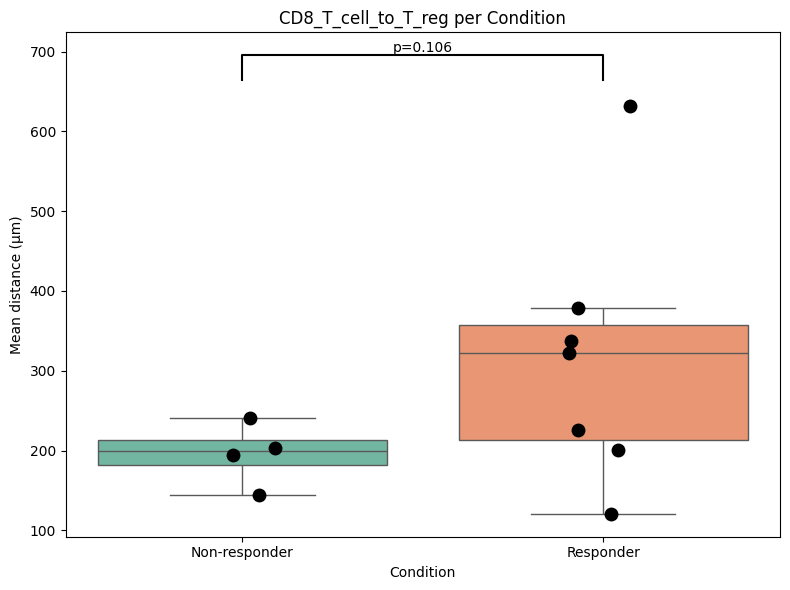

Condition
Non-responder    452.459231
Responder        809.102984
Name: mean, dtype: float64


/tmp/ipykernel_15461/3301968846.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


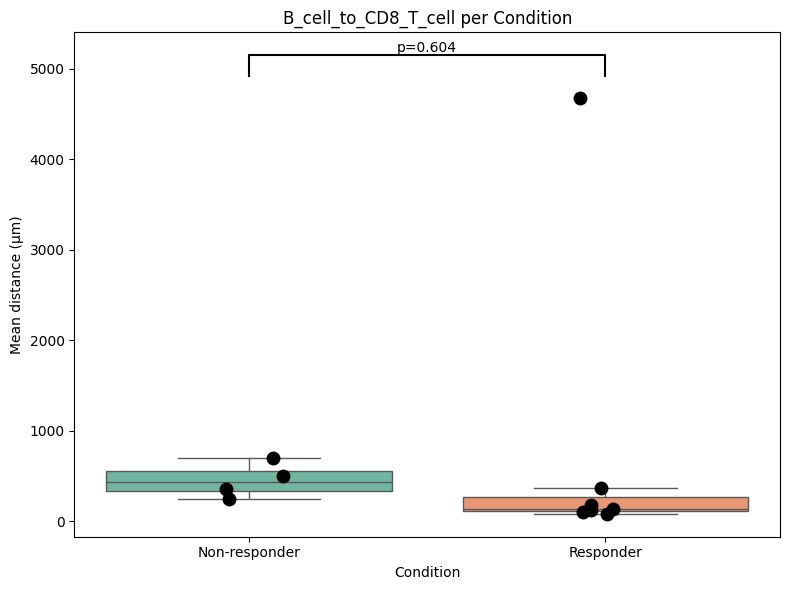

Condition
Non-responder     323.602109
Responder        1706.923545
Name: mean, dtype: float64


/tmp/ipykernel_15461/3301968846.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


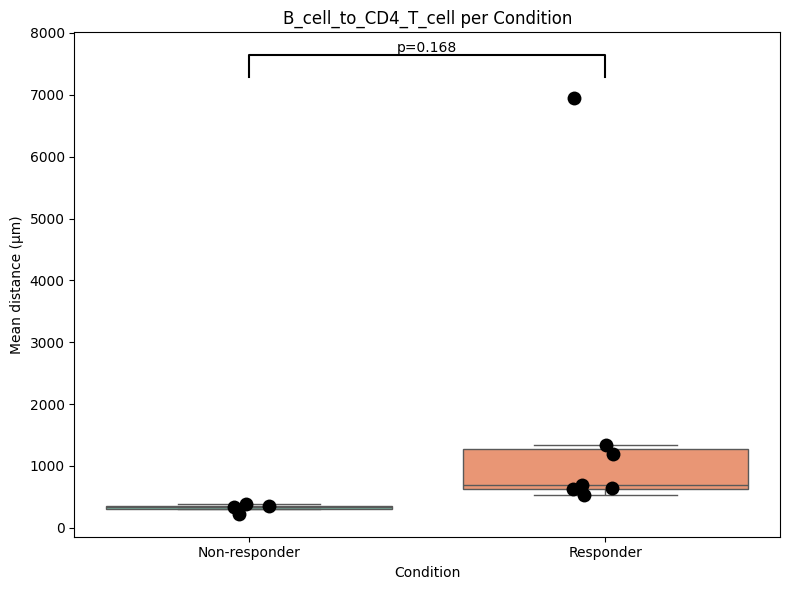

Condition
Non-responder    512.374288
Responder        770.483037
Name: mean, dtype: float64


/tmp/ipykernel_15461/3301968846.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


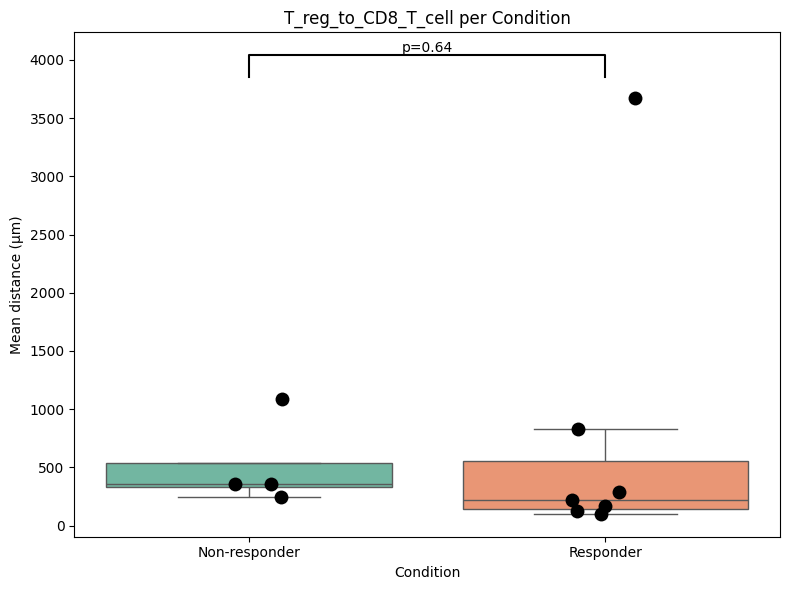

Condition
Non-responder    808.081549
Responder        367.106016
Name: mean, dtype: float64


/tmp/ipykernel_15461/3301968846.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


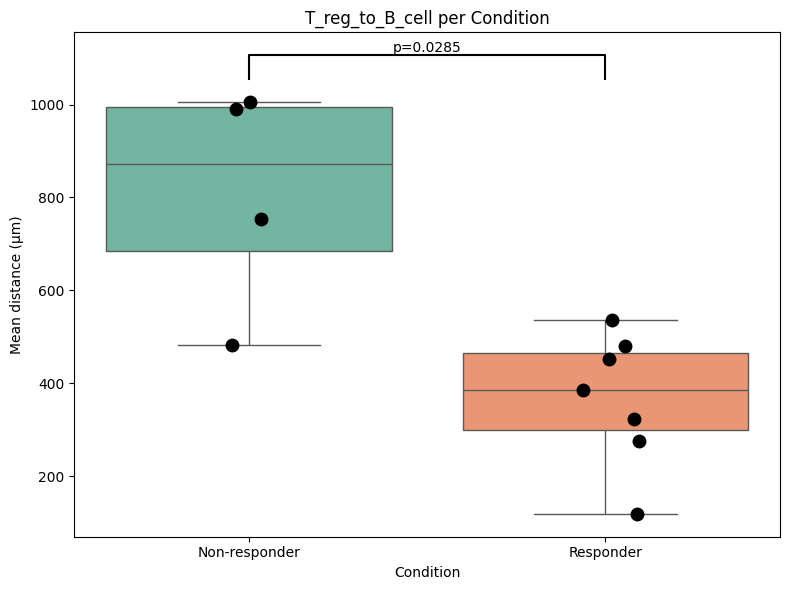

/tmp/ipykernel_15461/3301968846.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


Condition
Non-responder    9439.733557
Responder        7217.733295
Name: mean, dtype: float64


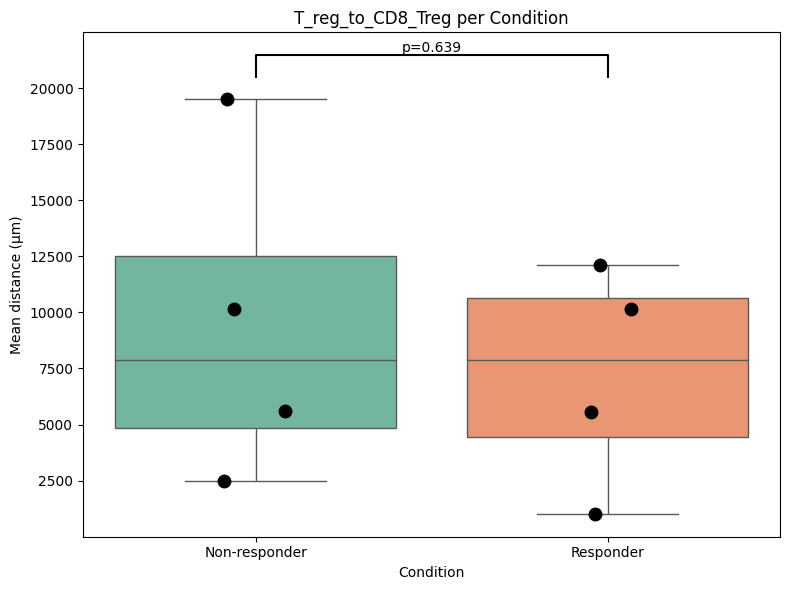

Condition
Non-responder     403.186897
Responder        2088.932234
Name: mean, dtype: float64


/tmp/ipykernel_15461/3301968846.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


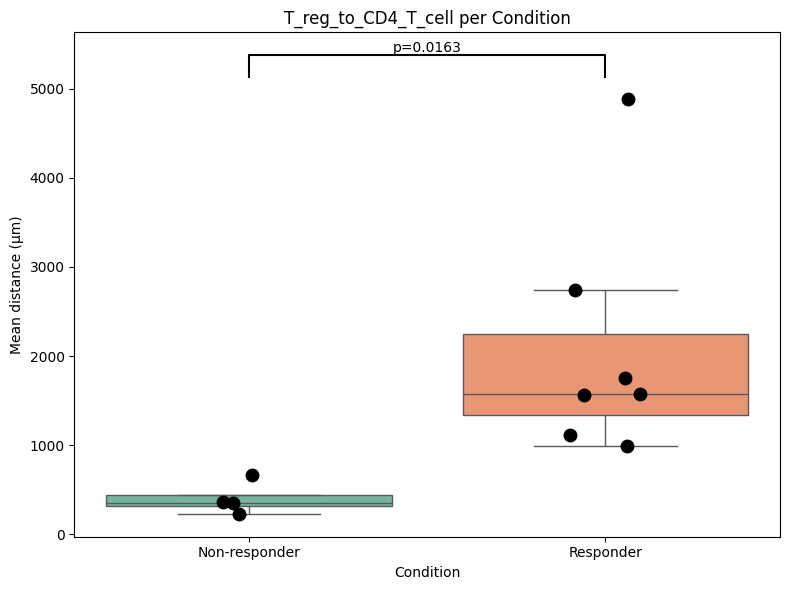

Condition
Non-responder    1046.427538
Responder        2276.800666
Name: mean, dtype: float64


/tmp/ipykernel_15461/3301968846.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


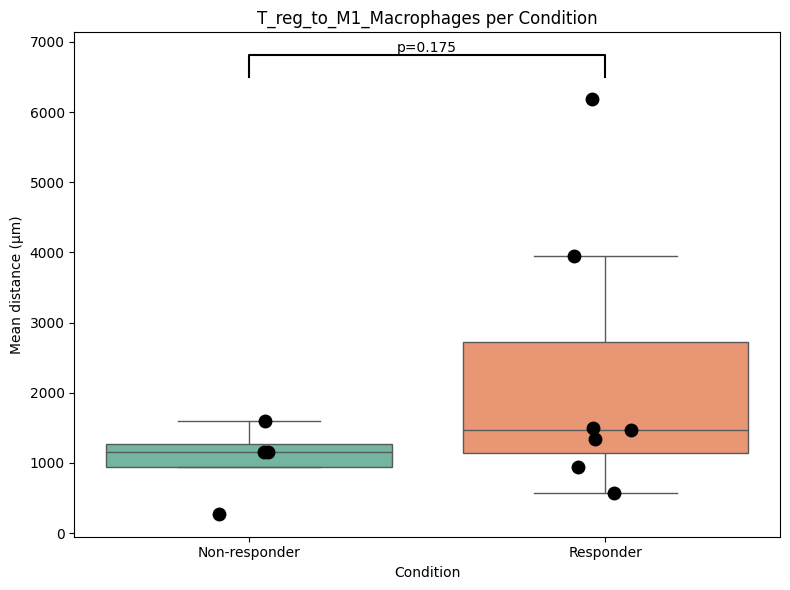

Condition
Non-responder    1321.325887
Responder        8224.242353
Name: mean, dtype: float64


/tmp/ipykernel_15461/3301968846.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


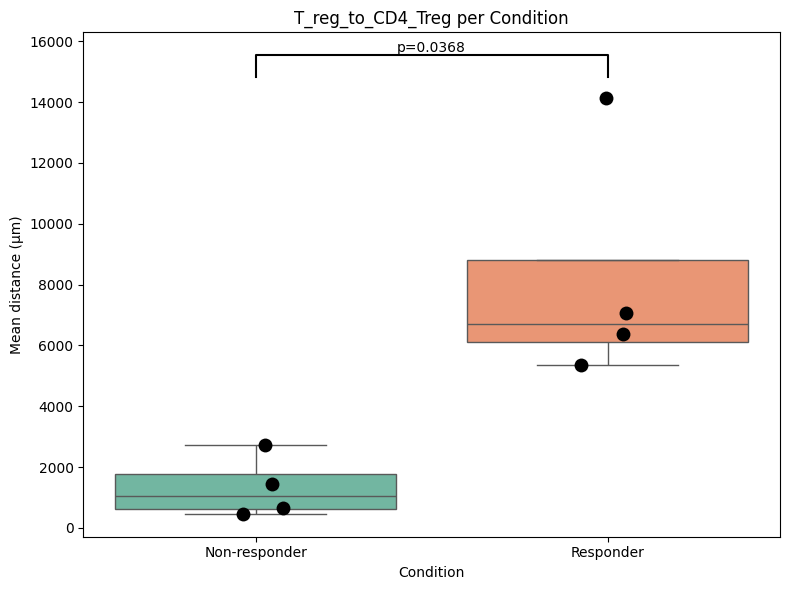

Condition
Non-responder    7864.110606
Responder        1587.723507
Name: mean, dtype: float64


/tmp/ipykernel_15461/3301968846.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


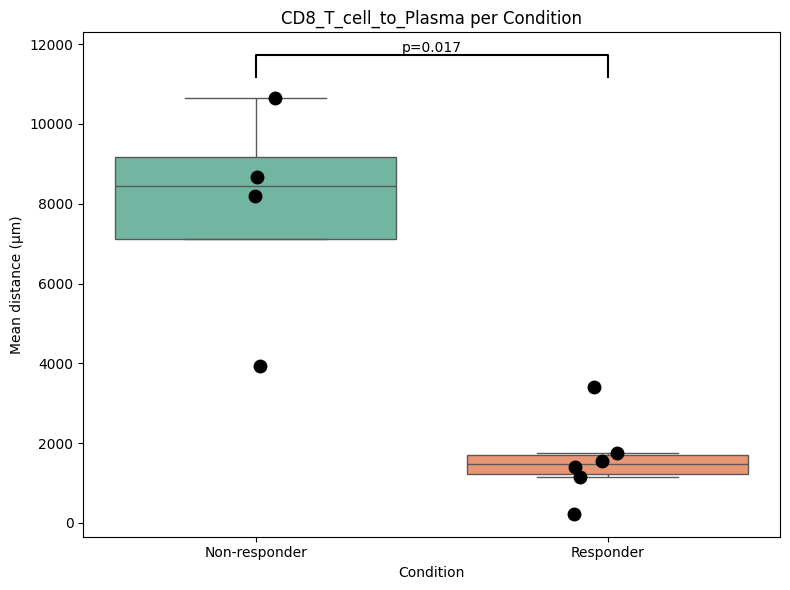

Condition
Non-responder    6431.729180
Responder        2031.395505
Name: mean, dtype: float64


/tmp/ipykernel_15461/3301968846.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


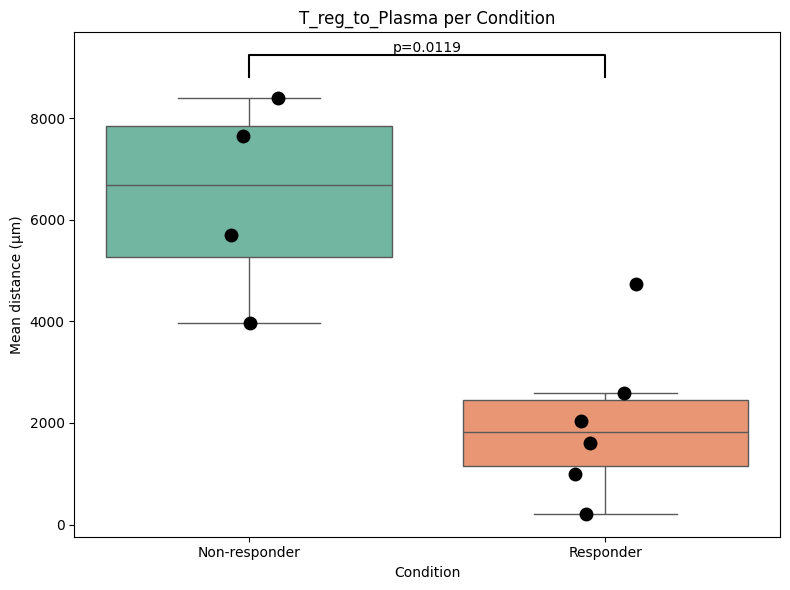

Condition
Non-responder    3011.755248
Responder        3005.535338
Name: mean, dtype: float64


/tmp/ipykernel_15461/3301968846.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


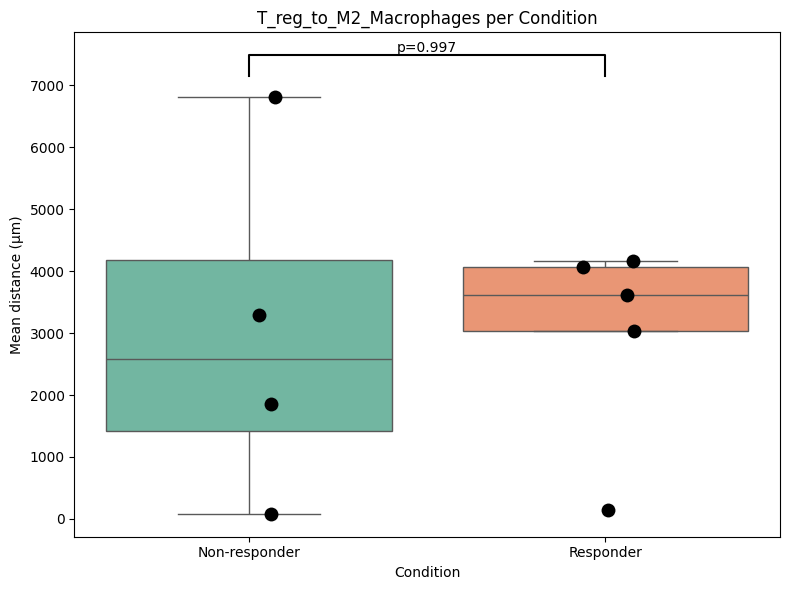

Condition
Non-responder    6176.356644
Responder        1894.016820
Name: mean, dtype: float64


/tmp/ipykernel_15461/3301968846.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


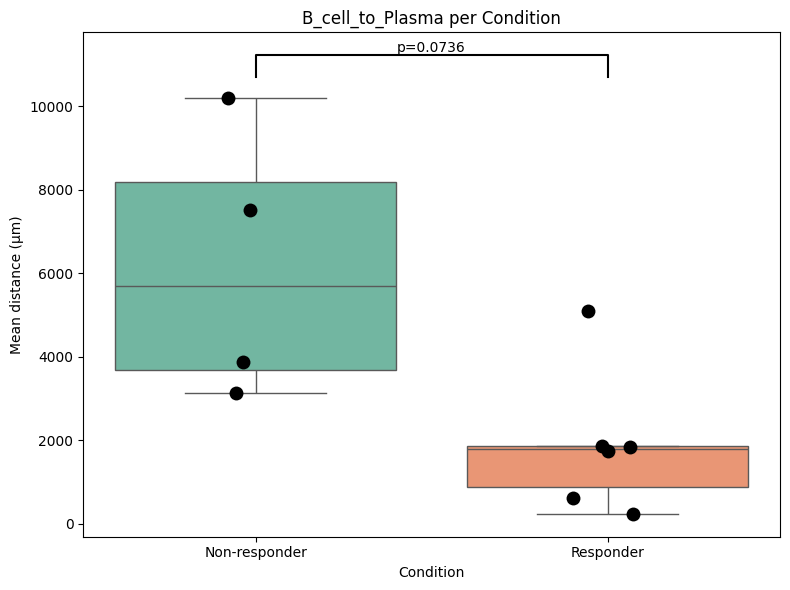

In [266]:
order_conditions = ['Non-responder','Responder']
for metric in sub_sub_res_Df['metric'].unique():
    sub = sub_sub_res_Df[sub_sub_res_Df['metric'] == metric]
    print(sub.groupby('Condition')['mean'].mean())
    groups = [c for c in order_conditions if c in sub['Condition'].unique()]
    flierprops = dict(marker='o', markersize=0, linestyle='none')  # size 0 removes them
    plt.figure(figsize=(8,6))
    ax = sns.boxplot(
        data=sub,
        x='Condition',
        y='mean',
        palette='Set2',
        order=groups,
        flierprops=flierprops
    )
    sns.stripplot(
        data=sub,
        x='Condition',
        y='mean',
        color='black',
        size=10,
        jitter=True,
        ax=ax,
        order=groups,
    )
    
    # Compute pairwise comparisons and annotate
    y_max = sub['mean'].max()
    h = y_max * 0.05  # height increment for annotations
    start = y_max + h
    step = h * 1.5
    
    for i, (g1, g2) in enumerate(combinations(groups, 2)):
        a = sub.loc[sub['Condition'] == g1, 'mean'].dropna()
        b = sub.loc[sub['Condition'] == g2, 'mean'].dropna()
        if len(a) > 0 and len(b) > 0:
            stat, p = stats.ttest_ind(a, b, equal_var=False)
            x1, x2 = list(groups).index(g1), list(groups).index(g2)
            y = start + step * i
            ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='k')
            ax.text((x1+x2)*.5, y+h, f"p={p:.3g}", ha='center', va='bottom', color='k')
    
    plt.title(f"{metric} per Condition")
    plt.ylabel("Mean distance (µm)")
    plt.xlabel("Condition")
    plt.tight_layout()
    plt.show()



# Immune cell type proportion differences

## First comparison: Responders vs Non-responders
Just internal tumor and no Peritumoral area

In [267]:
interest_sample_sub = sub_df_immune[sub_df_immune['sample_region'] == "BMSS23-8749_28835_tumor"]
sub_interest1 = pd.concat([sub_interest1, interest_sample_sub], axis=0)

In [268]:
sub_interest1['Condition'].unique()

array(['Responder', 'Non-responder'], dtype=object)

In [269]:
def t_test_plot(dataframe_interest, columns_interest, sample_order=None, t_test_type=ttest_ind):
    prop_table = pd.crosstab(
        [dataframe_interest[columns_interest], dataframe_interest['sample_region']], 
        dataframe_interest['combined_names'], 
        normalize='index'
    )
    prop_table.index.names = [columns_interest, 'sample_region']
    if sample_order is not None:
        # Reorder rows by desired condition order
        cond_order = pd.Categorical(
            prop_table.index.get_level_values(columns_interest),
            categories=sample_order,
            ordered=True
        )
        prop_table = prop_table.iloc[np.argsort(cond_order)]
         
    colors = [celltype_colors.get(ct, "#808080")  # fallback = grey if not in dict
              for ct in prop_table.columns]

    ax = prop_table.plot(kind='barh', stacked=True, figsize=(10, 6), color=colors)
    
    # add separator lines between conditions
    # get index levels
    conditions = prop_table.index.get_level_values(0)
    for i in range(1, len(conditions)):
        if conditions[i] != conditions[i-1]:
            ax.axhline(i-0.5, color="black", linewidth=1)  # separator
    
    # legend outside
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(False)
    
    plt.title('Proportion of Cell Types per Sample')
    plt.xlabel('Proportion of Cells')
    plt.ylabel('Sample (grouped by Condition)')
    plt.tight_layout()
    plt.show()



    prop_table[columns_interest] = prop_table.index.get_level_values(columns_interest)
    results = []

    conditions = prop_table[columns_interest].unique()
    
    for cell_type in prop_table.columns:
        if cell_type != columns_interest:  # skip metadata
            # Loop over all pairwise comparisons
            for cond1, cond2 in combinations(conditions, 2):
                group1 = prop_table.loc[prop_table[columns_interest] == cond1, cell_type]
                group2 = prop_table.loc[prop_table[columns_interest] == cond2, cell_type]
    
                mean1 = group1.mean()
                mean2 = group2.mean()

                if t_test_type == ttest_rel:
                    t_stat, p_val = t_test_type(group1, group2)
                else:
                    t_stat, p_val = t_test_type(group1, group2, equal_var=False)
    
                #t_stat, p_val = t_test_type(group1, group2, equal_var=False)
    
                direction = f"up_in_{cond1}" if mean1 > mean2 else f"up_in_{cond2}"
    
                results.append({
                    "cell_type": cell_type,
                    "comparison": f"{cond1}_vs_{cond2}",
                    f"{cond1}_mean": mean1,
                    f"{cond2}_mean": mean2,
                    "t_stat": t_stat,
                    "p_val": p_val,
                    "direction": direction
                })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Correct for multiple testing (FDR)
    results_df["p_adj"] = smm.multipletests(results_df["p_val"], method="fdr_bh")[1]
    
    return ax, results_df

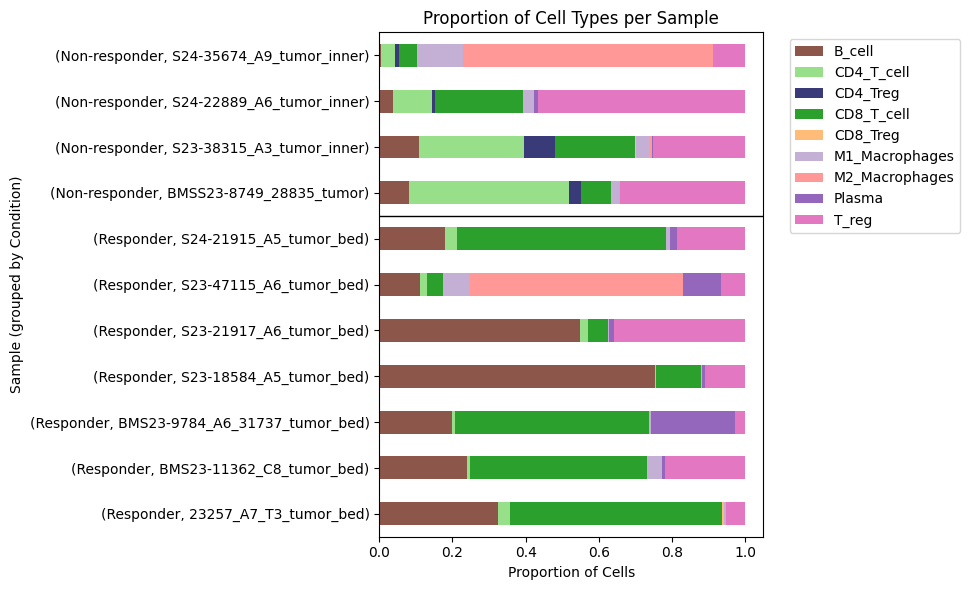

In [270]:
ax, results_df = t_test_plot(sub_interest1, "Condition",  sample_order=["Responder", "Non-responder"])

In [271]:
results_df[results_df['p_val']<0.05]

,cell_type,comparison,Responder_mean,Non-responder_mean,t_stat,p_val,direction,p_adj
0,B_cell,Responder_vs_Non-responder,0.336557,0.058069,3.086436,0.018388,up_in_Responder,0.165493


### All the p values for ecah comparison

In [272]:
results_df

,cell_type,comparison,Responder_mean,Non-responder_mean,t_stat,p_val,direction,p_adj
0,B_cell,Responder_vs_Non-responder,0.336557,0.058069,3.086436,0.018388,up_in_Responder,0.165493
1,CD4_T_cell,Responder_vs_Non-responder,0.018348,0.217302,-2.201151,0.114530,up_in_Non-responder,0.293158
2,CD4_Treg,Responder_vs_Non-responder,0.000116,0.033589,-1.907481,0.152502,up_in_Non-responder,0.293158
3,CD8_T_cell,Responder_vs_Non-responder,0.340584,0.147983,1.795174,0.108732,up_in_Responder,0.293158
4,CD8_Treg,Responder_vs_Non-responder,0.000724,0.000831,-0.149950,0.884136,up_in_Non-responder,0.884136
5,M1_Macrophages,Responder_vs_Non-responder,0.020460,0.053746,-1.262126,0.274472,up_in_Non-responder,0.352892
6,M2_Macrophages,Responder_vs_Non-responder,0.083507,0.173203,-0.474946,0.657074,up_in_Non-responder,0.739208
7,Plasma,Responder_vs_Non-responder,0.054078,0.003253,1.588713,0.162865,up_in_Responder,0.293158
8,T_reg,Responder_vs_Non-responder,0.145626,0.312024,-1.522581,0.199122,up_in_Non-responder,0.298683


### Ratio of CD8_T_cell and Tregs

Condition
Non-responder    0.521688
Responder        5.273660
Name: ratio, dtype: float64


/tmp/ipykernel_15461/3234071789.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


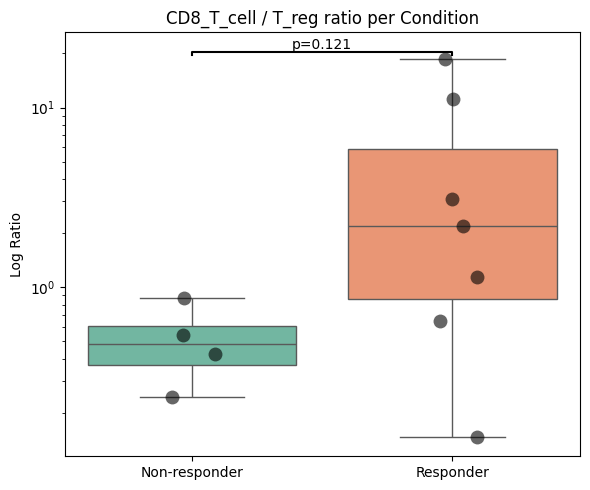

In [273]:
flierprops = dict(marker='o', markersize=0, linestyle='none')


values_per_Sample = pd.crosstab(
    [sub_interest1['Condition'], sub_interest1['sample_region']],
    sub_interest1['combined_names'],
)

numerator = 'CD8_T_cell'
denominator = 'T_reg'


ratios = (
    values_per_Sample[numerator] /
    values_per_Sample[denominator].replace(0, np.nan)
).rename('ratio')

ratios_df = ratios.reset_index()

print(ratios_df.groupby('Condition')['ratio'].mean())


fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    data=ratios_df,
    x='Condition',
    y='ratio',
    palette='Set2',
    flierprops=flierprops,
    log_scale=True,
    ax=ax
)

sns.stripplot(
    data=ratios_df,
    x='Condition',
    y='ratio',
    color='black',
    alpha=0.6,
    jitter=True,
    size=10,
    ax=ax
)

ax.set_title(f'{numerator} / {denominator} ratio per Condition')
ax.set_ylabel('Log Ratio')
ax.set_xlabel('')


test_df = ratios_df.dropna(subset=['ratio'])
groups = test_df['Condition'].unique()

y_max = test_df['ratio'].max()
h = y_max * 0.05
start = y_max + h
step = h * 1.5

for i, (g1, g2) in enumerate(combinations(groups, 2)):
    a = test_df.loc[test_df['Condition'] == g1, 'ratio']
    b = test_df.loc[test_df['Condition'] == g2, 'ratio']

    if len(a) > 0 and len(b) > 0:
        stat, p = ttest_ind(a, b, equal_var=False)

        x1, x2 = list(groups).index(g1), list(groups).index(g2)
        y = start + step * i

        ax.plot(
            [x1, x1, x2, x2],
            [y, y + h, y + h, y],
            lw=1.5,
            c='k'
        )

        ax.text(
            (x1 + x2) * 0.5,
            y + h,
            f"p={p:.3g}",
            ha='center',
            va='bottom',
            color='k'
        )

plt.tight_layout()
plt.show()


In [274]:
ratios_df

,Condition,sample_region,ratio
0,Non-responder,BMSS23-8749_28835_tumor,0.243482
1,Non-responder,S23-38315_A3_tumor_inner,0.875421
2,Non-responder,S24-22889_A6_tumor_inner,0.424694
3,Non-responder,S24-35674_A9_tumor_inner,0.543155
4,Responder,23257_A7_T3_tumor_bed,11.100453
5,Responder,BMS23-11362_C8_tumor_bed,2.201015
6,Responder,BMS23-9784_A6_31737_tumor_bed,18.607354
7,Responder,S23-18584_A5_tumor_bed,1.136884
8,Responder,S23-21917_A6_tumor_bed,0.146667
9,Responder,S23-47115_A6_tumor_bed,0.645669


## Second comparison: Responders MSI high vs MSI low

In [275]:
sub_interest1 = sub_df_immune[sub_df_immune['Condition']=="Responder"]
sub_interest1 = sub_interest1[sub_interest1['ROI']!="tumor"]
sub_interest1['sample_region'].unique()

array(['23257_A7_T3_tumor_bed', 'BMS23-11362_C8_tumor_bed',
       'BMS23-9784_A6_31737_tumor_bed', 'S23-47115_A6_tumor_bed',
       'S23-18584_A5_tumor_bed', 'S24-21915_A5_tumor_bed',
       'S23-21917_A6_tumor_bed'], dtype=object)

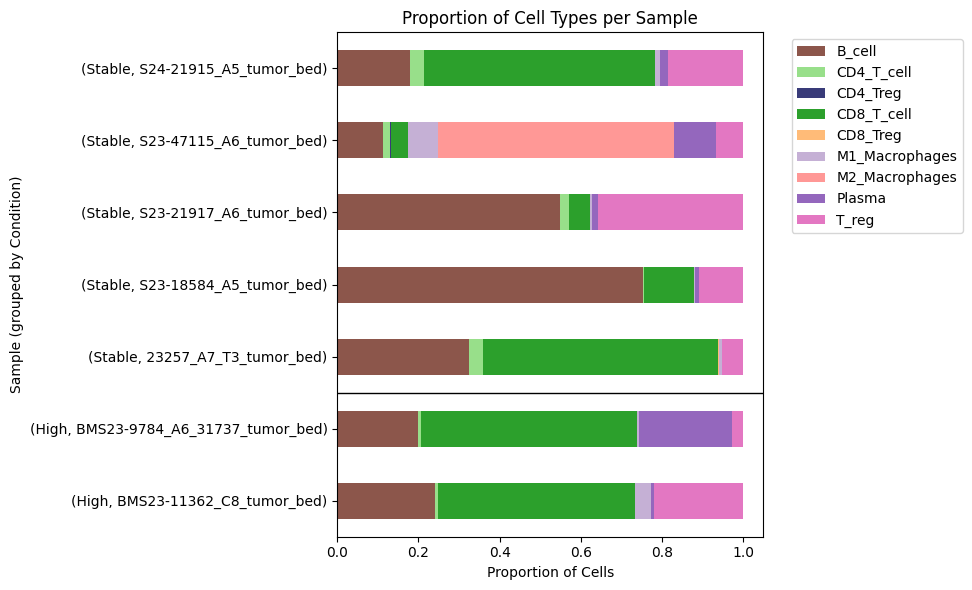

In [276]:
ax, results_df = t_test_plot(sub_interest1, "MSI")

In [277]:
results_df[results_df['p_val']<0.05]

,cell_type,comparison,High_mean,Stable_mean,t_stat,p_val,direction,p_adj


### All the p values for ecah comparison

In [278]:
results_df

,cell_type,comparison,High_mean,Stable_mean,t_stat,p_val,direction,p_adj
0,B_cell,High_vs_Stable,0.220209,0.383097,-1.352326,0.243991,up_in_Stable,0.731974
1,CD4_T_cell,High_vs_Stable,0.007424,0.022718,-2.653374,0.056101,up_in_Stable,0.504906
2,CD4_Treg,High_vs_Stable,0.000123,0.000113,0.070999,0.951085,up_in_High,0.951085
3,CD8_T_cell,High_vs_Stable,0.507534,0.273804,1.858113,0.132365,up_in_High,0.595642
4,CD8_Treg,High_vs_Stable,0.000269,0.000906,-0.742690,0.498906,up_in_Stable,0.857646
5,M1_Macrophages,High_vs_Stable,0.022246,0.019745,0.112296,0.919585,up_in_High,0.951085
6,M2_Macrophages,High_vs_Stable,0.000812,0.116584,-0.996556,0.375382,up_in_Stable,0.844609
7,Plasma,High_vs_Stable,0.117021,0.028901,0.781730,0.571764,up_in_High,0.857646
8,T_reg,High_vs_Stable,0.124362,0.154132,-0.268437,0.816753,up_in_Stable,0.951085


### Ratio of CD8_T_cell and Tregs

MSI
High      10.404184
Stable     3.221450
Name: ratio, dtype: float64


/tmp/ipykernel_15461/1212318464.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


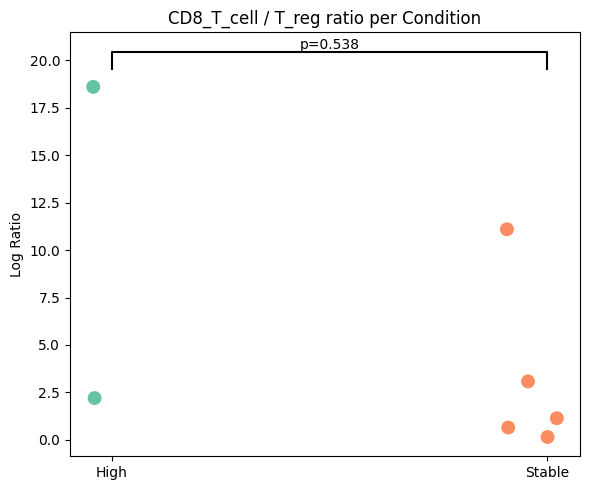

In [279]:
flierprops = dict(marker='o', markersize=0, linestyle='none')


values_per_Sample = pd.crosstab(
    [sub_interest1['MSI'], sub_interest1['sample_region']],
    sub_interest1['combined_names'],
)

numerator = 'CD8_T_cell'
denominator = 'T_reg'


ratios = (
    values_per_Sample[numerator] /
    values_per_Sample[denominator].replace(0, np.nan)
).rename('ratio')

ratios_df = ratios.reset_index()

print(ratios_df.groupby('MSI')['ratio'].mean())


fig, ax = plt.subplots(figsize=(6, 5))

sns.stripplot(
    data=ratios_df,
    x='MSI',
    y='ratio',
    color='black',
    alpha=1,
    jitter=True,
    palette='Set2', 
    size=10
)


ax.set_title(f'{numerator} / {denominator} ratio per Condition')
ax.set_ylabel('Log Ratio')
ax.set_xlabel('')


test_df = ratios_df.dropna(subset=['ratio'])
groups = test_df['MSI'].unique()

y_max = test_df['ratio'].max()
h = y_max * 0.05
start = y_max + h
step = h * 1.5

for i, (g1, g2) in enumerate(combinations(groups, 2)):
    a = test_df.loc[test_df['MSI'] == g1, 'ratio']
    b = test_df.loc[test_df['MSI'] == g2, 'ratio']

    if len(a) > 0 and len(b) > 0:
        stat, p = ttest_ind(a, b, equal_var=False)

        x1, x2 = list(groups).index(g1), list(groups).index(g2)
        y = start + step * i

        ax.plot(
            [x1, x1, x2, x2],
            [y, y + h, y + h, y],
            lw=1.5,
            c='k'
        )

        ax.text(
            (x1 + x2) * 0.5,
            y + h,
            f"p={p:.3g}",
            ha='center',
            va='bottom',
            color='k'
        )

plt.tight_layout()
plt.show()

In [280]:
ratios_df

,MSI,sample_region,ratio
0,High,BMS23-11362_C8_tumor_bed,2.201015
1,High,BMS23-9784_A6_31737_tumor_bed,18.607354
2,Stable,23257_A7_T3_tumor_bed,11.100453
3,Stable,S23-18584_A5_tumor_bed,1.136884
4,Stable,S23-21917_A6_tumor_bed,0.146667
5,Stable,S23-47115_A6_tumor_bed,0.645669
6,Stable,S24-21915_A5_tumor_bed,3.077577


## Third comparison: Baseline vs Resections: paired-test

In [281]:
sub_df_immune['Internal'].unique()

array(['Resection', 'Baseline', nan], dtype=object)

In [282]:
pd.crosstab(sub_df_immune['sample_region'], sub_df_immune['Internal'])

Internal,Baseline,Resection
sample_region,,
23257_A7_T3_tumor_bed,0,25390
BMS23-39313_C_tumor,2161,0
BMS23-6679_C_tumor,1188,0
BMS23-7393_C_tumor,3110,0
BMS23-9784_A6_31737_tumor_bed,0,77291
BMS24-11260_D_tumor,1015,0
BMSS23-8749_28835_tumor,0,6628
S23-47115_A6_tumor_bed,0,5660
S24-11672_G1_tumor,4667,0


In [283]:
sub_interest1 = sub_df_immune[sub_df_immune['Internal'].notna()]

In [284]:
sub_interest1['Sample_name'].unique()

array(['23257_A7_T3', 'BMS23-6679_C', 'BMSS23-8749_28835', 'S24-12214_C1',
       'BMS23-9784_A6_31737', 'S24-22889_A6', 'S23-47115_A6',
       'S24-11672_G1', 'BMS23-7393_C', 'BMS24-11260_D', 'BMS23-39313_C'],
      dtype=object)

In [285]:
sub_interest1 = sub_interest1[sub_interest1['Sample_name']!="S24-12214_C1"]

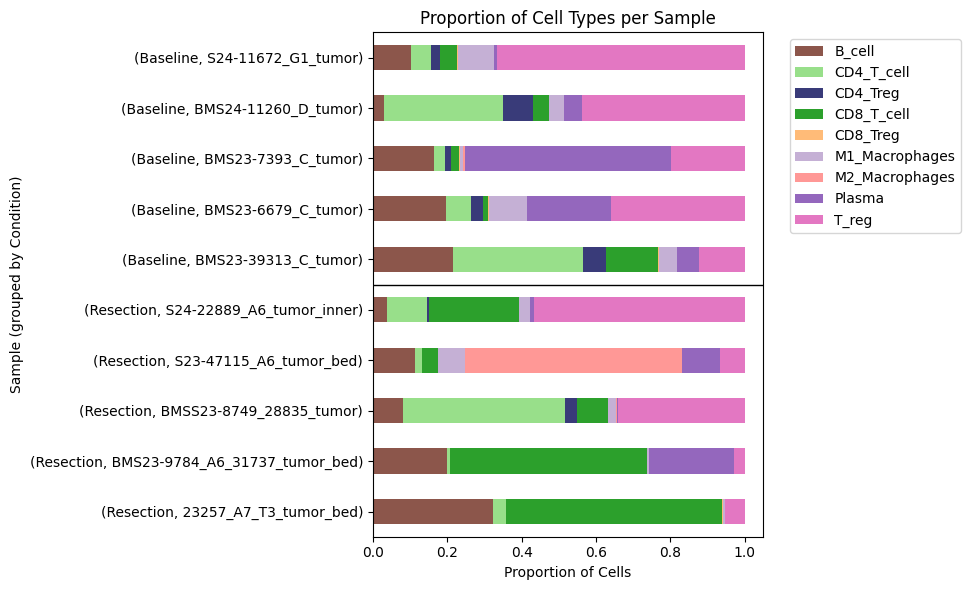

In [286]:
ax, results_df = t_test_plot(sub_interest1, "Internal", sample_order=["Resection", "Baseline"],t_test_type= ttest_rel)

In [287]:
results_df[results_df['p_val']<0.05]

,cell_type,comparison,Resection_mean,Baseline_mean,t_stat,p_val,direction,p_adj


In [288]:
results_df

,cell_type,comparison,Resection_mean,Baseline_mean,t_stat,p_val,direction,p_adj
0,B_cell,Resection_vs_Baseline,0.150689,0.141830,0.231915,0.827986,up_in_Resection,0.827986
1,CD4_T_cell,Resection_vs_Baseline,0.121132,0.163798,-0.321668,0.763812,up_in_Baseline,0.827986
2,CD4_Treg,Resection_vs_Baseline,0.007889,0.043231,-2.075847,0.106522,up_in_Baseline,0.479351
3,CD8_T_cell,Resection_vs_Baseline,0.295348,0.052774,2.370020,0.076819,up_in_Resection,0.479351
4,CD8_Treg,Resection_vs_Baseline,0.001015,0.001761,-0.884983,0.426158,up_in_Baseline,0.547918
5,M1_Macrophages,Resection_vs_Baseline,0.027228,0.059397,-1.318640,0.257720,up_in_Baseline,0.547918
6,M2_Macrophages,Resection_vs_Baseline,0.117192,0.001587,0.995106,0.376007,up_in_Resection,0.547918
7,Plasma,Resection_vs_Baseline,0.068167,0.178570,-0.989293,0.378522,up_in_Baseline,0.547918
8,T_reg,Resection_vs_Baseline,0.211341,0.357052,-1.556062,0.194677,up_in_Baseline,0.547918


### Ratio of CD8_T_cell and Tregs paired-test

Internal
Baseline     0.285606
Resection    6.204330
Name: ratio, dtype: float64


/tmp/ipykernel_15461/783965937.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


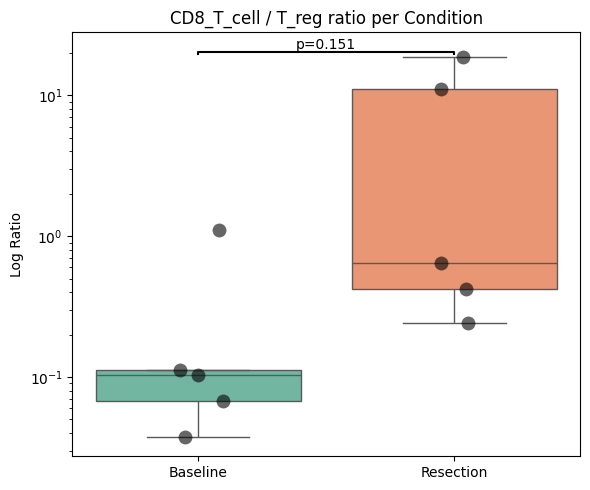

In [289]:
flierprops = dict(marker='o', markersize=0, linestyle='none')


values_per_Sample = pd.crosstab(
    [sub_interest1['Internal'], sub_interest1['sample_region']],
    sub_interest1['combined_names'],
)

numerator = 'CD8_T_cell'
denominator = 'T_reg'


ratios = (
    values_per_Sample[numerator] /
    values_per_Sample[denominator].replace(0, np.nan)
).rename('ratio')

ratios_df = ratios.reset_index()

print(ratios_df.groupby('Internal')['ratio'].mean())


fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    data=ratios_df,
    x='Internal',
    y='ratio',
    palette='Set2',
    flierprops=flierprops,
    log_scale=True,
    ax=ax
)

sns.stripplot(
    data=ratios_df,
    x='Internal',
    y='ratio',
    color='black',
    alpha=0.6,
    jitter=True,
    size=10,
    ax=ax
)

ax.set_title(f'{numerator} / {denominator} ratio per Condition')
ax.set_ylabel('Log Ratio')
ax.set_xlabel('')


test_df = ratios_df.dropna(subset=['ratio'])
groups = test_df['Internal'].unique()

y_max = test_df['ratio'].max()
h = y_max * 0.05
start = y_max + h
step = h * 1.5

for i, (g1, g2) in enumerate(combinations(groups, 2)):
    a = test_df.loc[test_df['Internal'] == g1, 'ratio']
    b = test_df.loc[test_df['Internal'] == g2, 'ratio']

    if len(a) > 0 and len(b) > 0:
        stat, p = ttest_ind(a, b)

        x1, x2 = list(groups).index(g1), list(groups).index(g2)
        y = start + step * i

        ax.plot(
            [x1, x1, x2, x2],
            [y, y + h, y + h, y],
            lw=1.5,
            c='k'
        )

        ax.text(
            (x1 + x2) * 0.5,
            y + h,
            f"p={p:.3g}",
            ha='center',
            va='bottom',
            color='k'
        )

plt.tight_layout()
plt.show()

In [290]:
ratios_df

,Internal,sample_region,ratio
0,Baseline,BMS23-39313_C_tumor,1.107807
1,Baseline,BMS23-6679_C_tumor,0.037471
2,Baseline,BMS23-7393_C_tumor,0.111470
3,Baseline,BMS24-11260_D_tumor,0.103604
4,Baseline,S24-11672_G1_tumor,0.067676
5,Resection,23257_A7_T3_tumor_bed,11.100453
6,Resection,BMS23-9784_A6_31737_tumor_bed,18.607354
7,Resection,BMSS23-8749_28835_tumor,0.243482
8,Resection,S23-47115_A6_tumor_bed,0.645669
9,Resection,S24-22889_A6_tumor_inner,0.424694


## 4 comparison: Baseline vs Resections for Responder: paired-test


In [291]:
test_to_subset = ['Responder','Baseline']
subset_table = sub_interest1[sub_interest1['Condition'].isin(test_to_subset)]
non_Responder = ['BMS23-6679_C_tumor','BMS24-11260_D_tumor']
subset_table = subset_table[~subset_table['sample_region'].isin(non_Responder)]
subset_table['sample_region'].unique()

array(['23257_A7_T3_tumor_bed', 'BMS23-9784_A6_31737_tumor_bed',
       'S23-47115_A6_tumor_bed', 'S24-11672_G1_tumor',
       'BMS23-7393_C_tumor', 'BMS23-39313_C_tumor'], dtype=object)

In [292]:
subset_table = subset_table[subset_table['Sample_name']!="S24-12214_C1"]

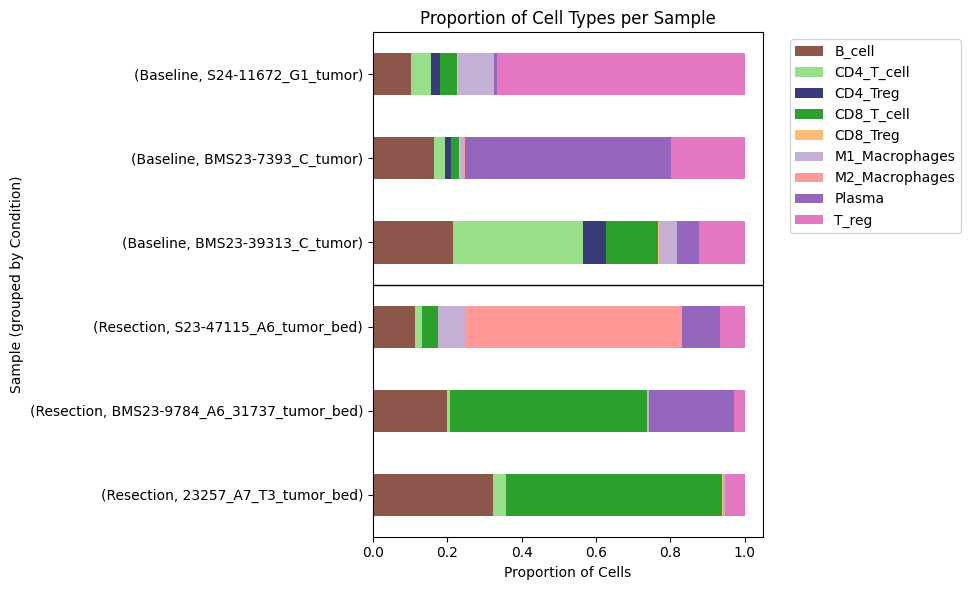

In [293]:
ax, results_df = t_test_plot(subset_table, "Internal", sample_order=["Resection", "Baseline"] ,t_test_type= ttest_rel)

In [294]:
results_df[results_df['p_val']<0.05]

,cell_type,comparison,Resection_mean,Baseline_mean,t_stat,p_val,direction,p_adj


### Ratio of CD8_T_cell and Tregs paired-test

Internal
Baseline      0.428984
Resection    10.117825
Name: ratio, dtype: float64


/tmp/ipykernel_15461/1347694456.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


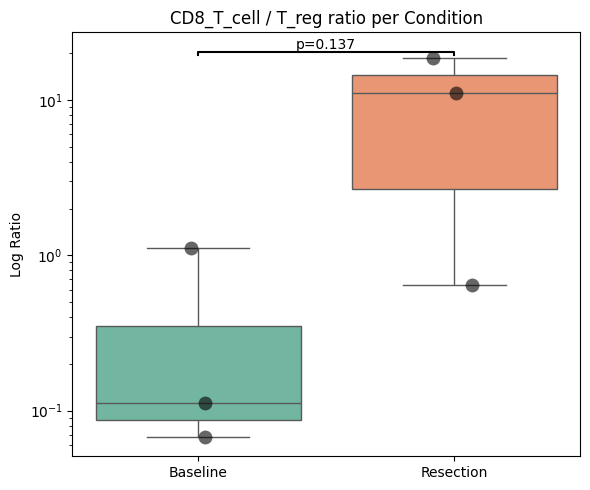

In [295]:
flierprops = dict(marker='o', markersize=0, linestyle='none')


values_per_Sample = pd.crosstab(
    [subset_table['Internal'], subset_table['sample_region']],
    subset_table['combined_names'],
)

numerator = 'CD8_T_cell'
denominator = 'T_reg'


ratios = (
    values_per_Sample[numerator] /
    values_per_Sample[denominator].replace(0, np.nan)
).rename('ratio')

ratios_df = ratios.reset_index()

print(ratios_df.groupby('Internal')['ratio'].mean())


fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    data=ratios_df,
    x='Internal',
    y='ratio',
    palette='Set2',
    flierprops=flierprops,
    log_scale=True,
    ax=ax
)

sns.stripplot(
    data=ratios_df,
    x='Internal',
    y='ratio',
    color='black',
    alpha=0.6,
    jitter=True,
    size=10,
    ax=ax
)

ax.set_title(f'{numerator} / {denominator} ratio per Condition')
ax.set_ylabel('Log Ratio')
ax.set_xlabel('')


test_df = ratios_df.dropna(subset=['ratio'])
groups = test_df['Internal'].unique()

y_max = test_df['ratio'].max()
h = y_max * 0.05
start = y_max + h
step = h * 1.5

for i, (g1, g2) in enumerate(combinations(groups, 2)):
    a = test_df.loc[test_df['Internal'] == g1, 'ratio']
    b = test_df.loc[test_df['Internal'] == g2, 'ratio']

    if len(a) > 0 and len(b) > 0:
        stat, p = ttest_ind(a, b)

        x1, x2 = list(groups).index(g1), list(groups).index(g2)
        y = start + step * i

        ax.plot(
            [x1, x1, x2, x2],
            [y, y + h, y + h, y],
            lw=1.5,
            c='k'
        )

        ax.text(
            (x1 + x2) * 0.5,
            y + h,
            f"p={p:.3g}",
            ha='center',
            va='bottom',
            color='k'
        )

plt.tight_layout()
plt.show()

In [296]:
ratios_df

,Internal,sample_region,ratio
0,Baseline,BMS23-39313_C_tumor,1.107807
1,Baseline,BMS23-7393_C_tumor,0.111470
2,Baseline,S24-11672_G1_tumor,0.067676
3,Resection,23257_A7_T3_tumor_bed,11.100453
4,Resection,BMS23-9784_A6_31737_tumor_bed,18.607354
5,Resection,S23-47115_A6_tumor_bed,0.645669


## 5 comparison: Baseline vs Resections for Non-responder: paired-test


In [297]:
test_to_subset = ['Non-responder','Baseline']
subset_table = sub_interest1[sub_interest1['Condition'].isin(test_to_subset)]
Responder = ['BMS23-7393_C_tumor']
subset_table = subset_table[~subset_table['sample_region'].isin(Responder)]
subset_table['sample_region'].unique()

array(['BMS23-6679_C_tumor', 'BMSS23-8749_28835_tumor',
       'S24-22889_A6_tumor_inner', 'BMS24-11260_D_tumor'], dtype=object)

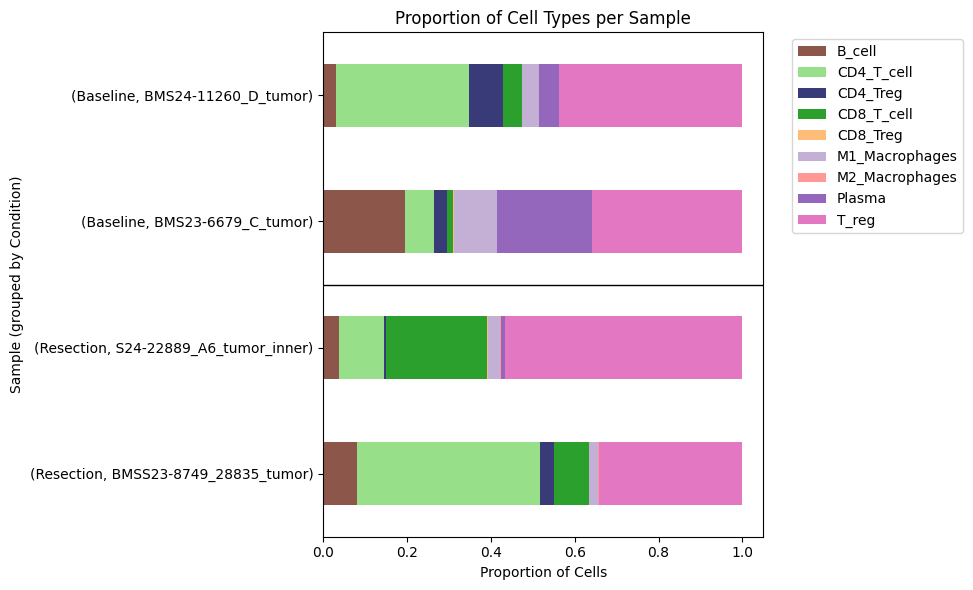

In [298]:
ax, results_df = t_test_plot(subset_table, "Internal", sample_order=["Resection", "Baseline"] ,t_test_type= ttest_rel)

In [299]:
results_df[results_df['p_val']<0.05]

,cell_type,comparison,Resection_mean,Baseline_mean,t_stat,p_val,direction,p_adj


### Ratio of CD8_T_cell and Tregs paired-test

Internal
Baseline     0.070537
Resection    0.334088
Name: ratio, dtype: float64


/tmp/ipykernel_15461/566583163.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


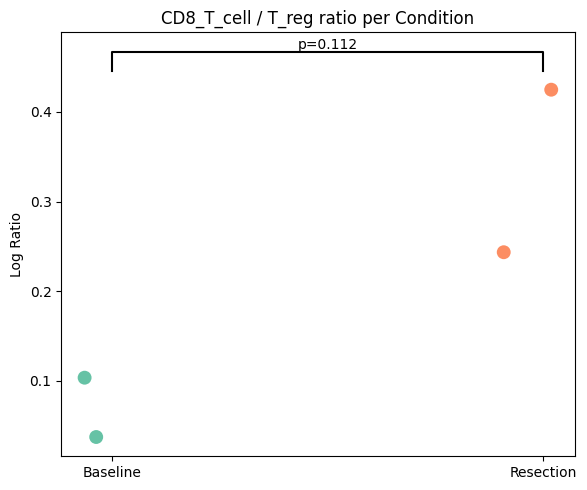

In [300]:
flierprops = dict(marker='o', markersize=0, linestyle='none')


values_per_Sample = pd.crosstab(
    [subset_table['Internal'], subset_table['sample_region']],
    subset_table['combined_names'],
)

numerator = 'CD8_T_cell'
denominator = 'T_reg'


ratios = (
    values_per_Sample[numerator] /
    values_per_Sample[denominator].replace(0, np.nan)
).rename('ratio')

ratios_df = ratios.reset_index()

print(ratios_df.groupby('Internal')['ratio'].mean())


fig, ax = plt.subplots(figsize=(6, 5))

sns.stripplot(
    data=ratios_df,
    x='Internal',
    y='ratio',
    color='black',
    alpha=1,
    jitter=True,
    palette='Set2', 
    size=10
)


ax.set_title(f'{numerator} / {denominator} ratio per Condition')
ax.set_ylabel('Log Ratio')
ax.set_xlabel('')


test_df = ratios_df.dropna(subset=['ratio'])
groups = test_df['Internal'].unique()

y_max = test_df['ratio'].max()
h = y_max * 0.05
start = y_max + h
step = h * 1.5

for i, (g1, g2) in enumerate(combinations(groups, 2)):
    a = test_df.loc[test_df['Internal'] == g1, 'ratio']
    b = test_df.loc[test_df['Internal'] == g2, 'ratio']

    if len(a) > 0 and len(b) > 0:
        stat, p = ttest_ind(a, b)

        x1, x2 = list(groups).index(g1), list(groups).index(g2)
        y = start + step * i

        ax.plot(
            [x1, x1, x2, x2],
            [y, y + h, y + h, y],
            lw=1.5,
            c='k'
        )

        ax.text(
            (x1 + x2) * 0.5,
            y + h,
            f"p={p:.3g}",
            ha='center',
            va='bottom',
            color='k'
        )

plt.tight_layout()
plt.show()

In [301]:
ratios_df

,Internal,sample_region,ratio
0,Baseline,BMS23-6679_C_tumor,0.037471
1,Baseline,BMS24-11260_D_tumor,0.103604
2,Resection,BMSS23-8749_28835_tumor,0.243482
3,Resection,S24-22889_A6_tumor_inner,0.424694


## 6 comparison: within Baseline: Responders vs Non-responders

In [302]:
sub_interest1 = sub_df_immune[sub_df_immune['Internal']=="Baseline"]

In [303]:
sub_interest1['Baseline_comp']='Responder'
sub_interest1.loc[sub_interest1['sample_region'] == 'BMS24-11260_D_tumor', 'Baseline_comp'] = 'Non-responder'
sub_interest1.loc[sub_interest1['sample_region'] == 'BMS23-6679_C_tumor', 'Baseline_comp'] = 'Non-responder'

/tmp/ipykernel_15461/2083488142.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_interest1['Baseline_comp']='Responder'


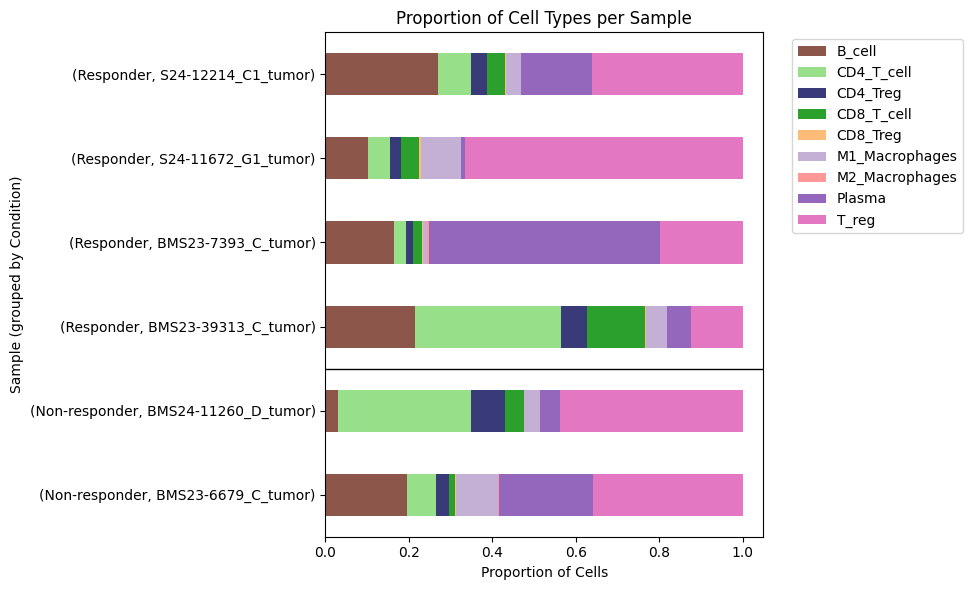

In [304]:
ax, results_df = t_test_plot(sub_interest1, "Baseline_comp")

### Ratio of CD8_T_cell and Tregs

Baseline_comp
Non-responder    0.070537
Responder        0.351211
Name: ratio, dtype: float64


/tmp/ipykernel_15461/2385383878.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


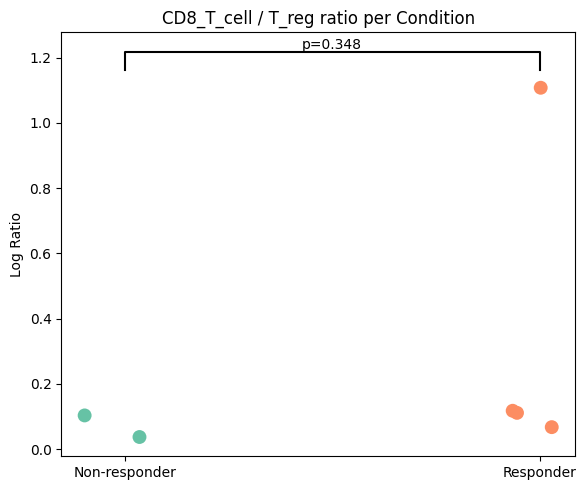

In [305]:
flierprops = dict(marker='o', markersize=0, linestyle='none')


values_per_Sample = pd.crosstab(
    [sub_interest1['Baseline_comp'], sub_interest1['sample_region']],
    sub_interest1['combined_names'],
)

numerator = 'CD8_T_cell'
denominator = 'T_reg'


ratios = (
    values_per_Sample[numerator] /
    values_per_Sample[denominator].replace(0, np.nan)
).rename('ratio')

ratios_df = ratios.reset_index()

print(ratios_df.groupby('Baseline_comp')['ratio'].mean())


fig, ax = plt.subplots(figsize=(6, 5))

sns.stripplot(
    data=ratios_df,
    x='Baseline_comp',
    y='ratio',
    color='black',
    alpha=1,
    jitter=True,
    palette='Set2',
    size=10
)

ax.set_title(f'{numerator} / {denominator} ratio per Condition')
ax.set_ylabel('Log Ratio')
ax.set_xlabel('')


test_df = ratios_df.dropna(subset=['ratio'])
groups = test_df['Baseline_comp'].unique()

y_max = test_df['ratio'].max()
h = y_max * 0.05
start = y_max + h
step = h * 1.5

for i, (g1, g2) in enumerate(combinations(groups, 2)):
    a = test_df.loc[test_df['Baseline_comp'] == g1, 'ratio']
    b = test_df.loc[test_df['Baseline_comp'] == g2, 'ratio']

    if len(a) > 0 and len(b) > 0:
        stat, p = ttest_ind(a, b, equal_var=False)

        x1, x2 = list(groups).index(g1), list(groups).index(g2)
        y = start + step * i

        ax.plot(
            [x1, x1, x2, x2],
            [y, y + h, y + h, y],
            lw=1.5,
            c='k'
        )

        ax.text(
            (x1 + x2) * 0.5,
            y + h,
            f"p={p:.3g}",
            ha='center',
            va='bottom',
            color='k'
        )

plt.tight_layout()
plt.show()

In [306]:
ratios_df

,Baseline_comp,sample_region,ratio
0,Non-responder,BMS23-6679_C_tumor,0.037471
1,Non-responder,BMS24-11260_D_tumor,0.103604
2,Responder,BMS23-39313_C_tumor,1.107807
3,Responder,BMS23-7393_C_tumor,0.111470
4,Responder,S24-11672_G1_tumor,0.067676
5,Responder,S24-12214_C1_tumor,0.117890


## 7: comparison based on Non-reponders with WT and mutations of interest


In [307]:
sample_to_subset = ['S24-35674_A9_tumor_inner','S24-22889_A6_tumor_inner','S23-38315_A3_tumor_inner','BMSS23-8749_28835_tumor']
sub_interest1 = sub_df_immune[sub_df_immune['sample_region'].isin(sample_to_subset)]

In [308]:
sub_interest1['mutation_state']='WT'
sub_interest1.loc[sub_interest1['sample_region'] == 'S24-22889_A6_tumor_inner', 'mutation_state'] = 'BRAF_V600R'
sub_interest1.loc[sub_interest1['sample_region'] == 'S24-35674_A9_tumor_inner', 'mutation_state'] = 'KRAS_G12D'

/tmp/ipykernel_15461/224637411.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_interest1['mutation_state']='WT'


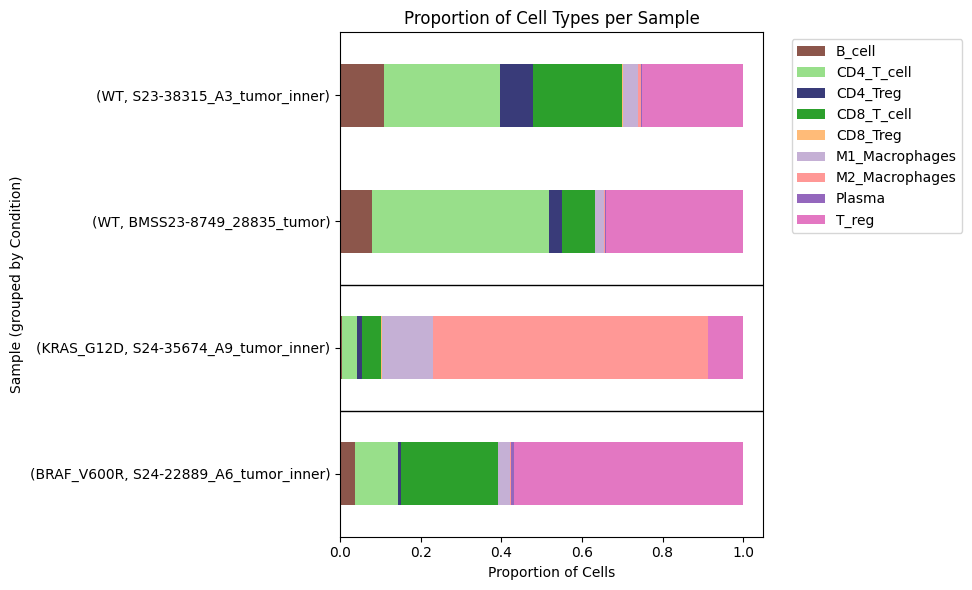

/usr/local/lib64/python3.9/site-packages/scipy/stats/_stats_py.py:1087: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/usr/local/lib64/python3.9/site-packages/scipy/stats/_stats_py.py:1087: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


In [309]:
ax, results_df = t_test_plot(sub_interest1, "mutation_state")

In [310]:
results_df[results_df['p_val']<0.05]

,cell_type,comparison,BRAF_V600R_mean,KRAS_G12D_mean,t_stat,p_val,direction,WT_mean,p_adj


### Ratio of CD8_T_cell and Tregs

mutation_state
BRAF_V600R    0.424694
KRAS_G12D     0.543155
WT            0.559451
Name: ratio, dtype: float64


/tmp/ipykernel_15461/3116016190.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


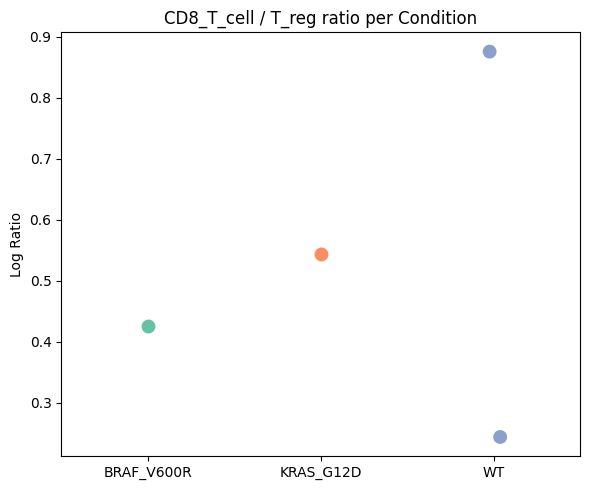

In [311]:
values_per_Sample = pd.crosstab(
        [sub_interest1['mutation_state'], sub_interest1['sample_region']], 
        sub_interest1['combined_names'], 
    )

numerator = 'CD8_T_cell'
denominator = 'T_reg'

ratios = (
    values_per_Sample[numerator] /
    values_per_Sample[denominator].replace(0, np.nan)
).rename('ratio')

ratios_df = ratios.reset_index() 
print(ratios_df.groupby('mutation_state')['ratio'].mean())

# Plot
plt.figure(figsize=(6, 5))
sns.stripplot(
    data=ratios_df,
    x='mutation_state',
    y='ratio',
    color='black',
    alpha=1,
    jitter=True,
    palette='Set2',
    size=10
)
 
plt.title(f'{numerator} / {denominator} ratio per Condition')
plt.ylabel('Log Ratio')
plt.xlabel('')
plt.tight_layout()
plt.show()

In [312]:
ratios_df

,mutation_state,sample_region,ratio
0,BRAF_V600R,S24-22889_A6_tumor_inner,0.424694
1,KRAS_G12D,S24-35674_A9_tumor_inner,0.543155
2,WT,BMSS23-8749_28835_tumor,0.243482
3,WT,S23-38315_A3_tumor_inner,0.875421


## 8: All samples


In [313]:
sub_df_immune['All'] = sub_df_immune['Internal'].values
sub_df_immune.loc[sub_df_immune['Sample_name'] == '23257_A7_T3', 'All'] = 'Responder'
sub_df_immune.loc[sub_df_immune['Sample_name'] == 'BMS23-11362_C8', 'All'] = 'Responder'
sub_df_immune.loc[sub_df_immune['Sample_name'] == 'BMS23-9784_A6_31737', 'All'] = 'Responder'
sub_df_immune.loc[sub_df_immune['Sample_name'] == 'S23-18584_A5', 'All'] = 'Responder'
sub_df_immune.loc[sub_df_immune['Sample_name'] == 'S23-21917_A6', 'All'] = 'Responder'
sub_df_immune.loc[sub_df_immune['Sample_name'] == 'S23-47115_A6', 'All'] = 'Responder'
sub_df_immune.loc[sub_df_immune['Sample_name'] == 'S24-21915_A5', 'All'] = 'Responder'


sub_df_immune.loc[sub_df_immune['Sample_name'] == 'BMSS23-8749_28835', 'All'] = 'Non-Responder'
sub_df_immune.loc[sub_df_immune['Sample_name'] == 'S23-38315_A3', 'All'] = 'Non-Responder'
sub_df_immune.loc[sub_df_immune['Sample_name'] == 'S24-22889_A6', 'All'] = 'Non-Responder'
sub_df_immune.loc[sub_df_immune['Sample_name'] == 'S24-35674_A9', 'All'] = 'Non-Responder'



In [314]:
sub_df_immune['All'].unique()

array(['Responder', 'Baseline', 'Non-Responder'], dtype=object)

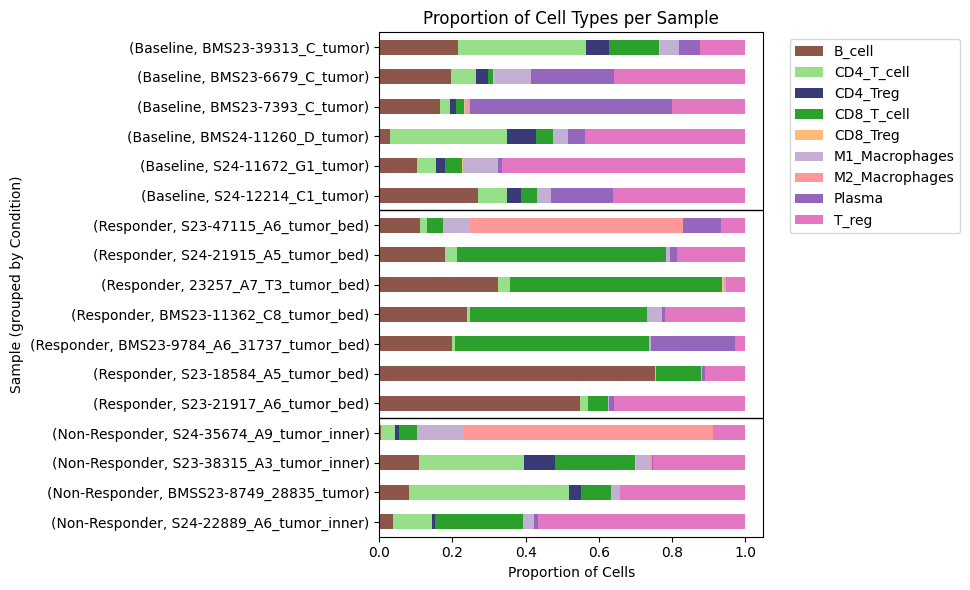

In [315]:
ax, results_df = t_test_plot(sub_df_immune, "All", sample_order=["Non-Responder", "Responder","Baseline"])

### Significant res

In [316]:
results_df[results_df['p_val']<0.05]

,cell_type,comparison,Non-Responder_mean,Responder_mean,t_stat,p_val,direction,Baseline_mean,p_adj
0,B_cell,Non-Responder_vs_Responder,0.058069,0.336557,-3.086436,0.018388,up_in_Responder,NaN,0.206684
1,B_cell,Non-Responder_vs_Baseline,0.058069,NaN,-2.524912,0.036227,up_in_Baseline,0.163057,0.241067
8,CD4_Treg,Responder_vs_Baseline,NaN,0.000116,-4.171513,0.008725,up_in_Baseline,0.042276,0.206684
11,CD8_T_cell,Responder_vs_Baseline,NaN,0.340584,2.970461,0.022965,up_in_Responder,0.051050,0.206684
26,T_reg,Responder_vs_Baseline,NaN,0.145626,-2.375278,0.044642,up_in_Baseline,0.357529,0.241067


### All res

In [317]:
results_df

,cell_type,comparison,Non-Responder_mean,Responder_mean,t_stat,p_val,direction,Baseline_mean,p_adj
0,B_cell,Non-Responder_vs_Responder,0.058069,0.336557,-3.086436,0.018388,up_in_Responder,NaN,0.206684
1,B_cell,Non-Responder_vs_Baseline,0.058069,NaN,-2.524912,0.036227,up_in_Baseline,0.163057,0.241067
2,B_cell,Responder_vs_Baseline,NaN,0.336557,1.845505,0.103018,up_in_Responder,0.163057,0.281120
3,CD4_T_cell,Non-Responder_vs_Responder,0.217302,0.018348,2.201151,0.114530,up_in_Non-Responder,NaN,0.281120
4,CD4_T_cell,Non-Responder_vs_Baseline,0.217302,NaN,0.625600,0.556713,up_in_Non-Responder,0.149975,0.683239
5,CD4_T_cell,Responder_vs_Baseline,NaN,0.018348,-2.237812,0.074694,up_in_Baseline,0.149975,0.281120
6,CD4_Treg,Non-Responder_vs_Responder,0.033589,0.000116,1.907481,0.152502,up_in_Non-Responder,NaN,0.293158
7,CD4_Treg,Non-Responder_vs_Baseline,0.033589,NaN,-0.428987,0.685819,up_in_Baseline,0.042276,0.771547
8,CD4_Treg,Responder_vs_Baseline,NaN,0.000116,-4.171513,0.008725,up_in_Baseline,0.042276,0.206684
9,CD8_T_cell,Non-Responder_vs_Responder,0.147983,0.340584,-1.795174,0.108732,up_in_Responder,NaN,0.281120


All
Baseline         0.257653
Non-Responder    0.521688
Responder        5.273660
Name: ratio, dtype: float64


/tmp/ipykernel_15461/274400879.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


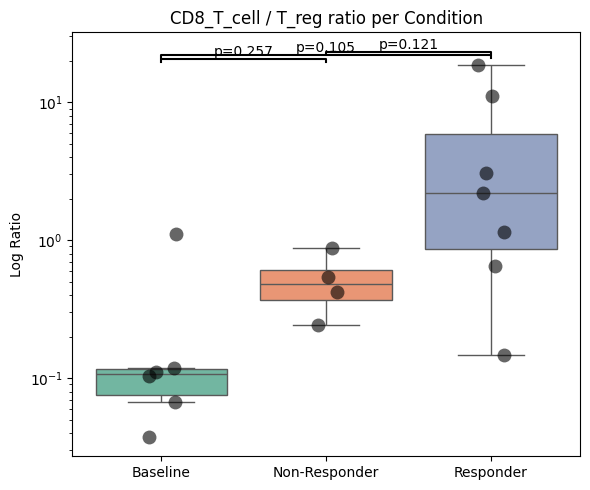

In [318]:
flierprops = dict(marker='o', markersize=0, linestyle='none')


values_per_Sample = pd.crosstab(
    [sub_df_immune['All'], sub_df_immune['sample_region']],
    sub_df_immune['combined_names'],
)

numerator = 'CD8_T_cell'
denominator = 'T_reg'


ratios = (
    values_per_Sample[numerator] /
    values_per_Sample[denominator].replace(0, np.nan)
).rename('ratio')

ratios_df = ratios.reset_index()

print(ratios_df.groupby('All')['ratio'].mean())


fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    data=ratios_df,
    x='All',
    y='ratio',
    palette='Set2',
    flierprops=flierprops,
    log_scale=True,
    ax=ax
)

sns.stripplot(
    data=ratios_df,
    x='All',
    y='ratio',
    color='black',
    alpha=0.6,
    jitter=True,
    size=10,
    ax=ax
)

ax.set_title(f'{numerator} / {denominator} ratio per Condition')
ax.set_ylabel('Log Ratio')
ax.set_xlabel('')


test_df = ratios_df.dropna(subset=['ratio'])
groups = test_df['All'].unique()

y_max = test_df['ratio'].max()
h = y_max * 0.05
start = y_max + h
step = h * 1.5

for i, (g1, g2) in enumerate(combinations(groups, 2)):
    a = test_df.loc[test_df['All'] == g1, 'ratio']
    b = test_df.loc[test_df['All'] == g2, 'ratio']

    if len(a) > 0 and len(b) > 0:
        stat, p = ttest_ind(a, b, equal_var=False)

        x1, x2 = list(groups).index(g1), list(groups).index(g2)
        y = start + step * i

        ax.plot(
            [x1, x1, x2, x2],
            [y, y + h, y + h, y],
            lw=1.5,
            c='k'
        )

        ax.text(
            (x1 + x2) * 0.5,
            y + h,
            f"p={p:.3g}",
            ha='center',
            va='bottom',
            color='k'
        )

plt.tight_layout()
plt.show()